# **Portfolio VaR & ES**

**Course:** Quantitative Financial Risk Management — Charles Bos, 2026/3

**Group:** Group 20

**Members:** A. Koulopoulos (Andreas), H. Ghoussy (Hamza), M. Péter (Milán), S.V. Nanewar (Shubham Vijay), S.Y. Kukreja (Siddharth)


In [ ]:
import itertools
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from arch import arch_model
from scipy import stats
from scipy.optimize import minimize
from scipy.stats import binom, norm, t
warnings.filterwarnings("ignore")

# Data paths 
DATA_RAW     = "data/data_real.xlsx"
DATA_PRICES  = "data/prices_clean.csv"
DATA_RETURNS = "data/returns_clean.csv"

# Time periods 
PRE_START    = "2015-01-01"
PRE_END      = "2016-12-31"
SAMPLE_START = "2017-01-01"
SAMPLE_END   = "2026-03-31"

# Portfolio 
LOAN_WEIGHT     = 0.20        # two-fund split: 20% bond, 80% tangency portfolio
RISKY_WEIGHT    = 0.80
WEIGHT_MIN      = 0.10
WEIGHT_MAX      = 0.30
LOAN_SPREAD_BPS = 150
TRADING_DAYS    = 252
PORTFOLIO_VALUE = 1_000_000

# Asset lists 
STOCKS_USD = ["ASML", "SHELL", "JPM"]
INDEX_USD  = ["STOXX50", "SP500"]
RISKY_USD  = STOCKS_USD + INDEX_USD

STOCKS = ["ASML", "SHELL", "JPM_EUR"]
INDEX  = ["STOXX50", "SP500_EUR"]
RISKY  = STOCKS + INDEX

FX       = ["EURUSD"]
RATE     = ["EURIBOR3M"]
ALL_COLS = STOCKS_USD + INDEX_USD + FX + RATE   

# NOTE: JPM_EUR and SP500_EUR in DATA_RETURNS are EUR-adjusted log-returns
#       (r_USD - r_EURUSD). Use RISKY for VaR/ES/portfolio P&L.
#       Use RISKY_USD vs RISKY for FX risk decomposition.


# Populated after running Section 4 — paste output back in
EURIBOR_T0    = -0.319000
LOAN_COUPON   = 0.011810
LOAN_MATURITY = 9.242984
LOAN_MOD_DUR  = 9.135099   # fixed-rate duration
WEIGHTS = {
    "ASML": 0.160000,
    "SHELL": 0.080000,
    "JPM_EUR": 0.240000,
    "STOXX50": 0.080000,
    "SP500_EUR": 0.240000,
    "LOAN": 0.200000,
}

## **Tasks 1–2: data import, cleaning, returns, portfolio weights**

In [94]:
# 1. Imports

# Equity & FX 
equity_tickers = ["ASML.AS", "JPM", "SHELL.AS", "^GSPC", "^STOXX50E", "EURUSD=X"]

raw_equity = yf.download(
    equity_tickers, start=PRE_START, end=SAMPLE_END, auto_adjust=True
)["Close"]

raw_equity = raw_equity.rename(columns={
    "ASML.AS": "ASML",
    "SHELL.AS": "SHELL",
    "^GSPC": "SP500",
    "^STOXX50E": "STOXX50",
    "EURUSD=X": "EURUSD",
})

# EURIBOR 3M from attached CSV
csv_path = "data/EURIBOR3m.csv"

euribor_raw = pd.read_csv(csv_path, header=None)

# keep only rows where first column looks like a date
date_mask = pd.to_datetime(euribor_raw[0], errors="coerce").notna()
euribor = euribor_raw.loc[date_mask, [0, 1]].copy()

euribor.columns = ["Date", "EURIBOR3M"]
euribor["Date"] = pd.to_datetime(euribor["Date"])
euribor["EURIBOR3M"] = pd.to_numeric(
    euribor["EURIBOR3M"].replace(".", pd.NA), errors="coerce"
)

euribor = euribor.set_index("Date").sort_index()
euribor = euribor.loc[PRE_START:SAMPLE_END]

# Merge on trading dates
data = raw_equity.join(euribor, how="left")

data.to_excel("data/data_real.xlsx")

[*********************100%***********************]  6 of 6 completed


In [95]:
# 2. Configuration

prices = pd.read_excel(DATA_RAW, index_col=0, parse_dates=True)
prices = prices[ALL_COLS]

print(f"Shape     : {prices.shape}")
print(f"Date range: {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"\nRaw NaN counts:\n{prices.isnull().sum().to_string()}")
print(prices.head())


Shape     : (2929, 7)
Date range: 2015-01-01 → 2026-03-30

Raw NaN counts:
ASML          52
SHELL         52
JPM          103
STOXX50      105
SP500        103
EURUSD         4
EURIBOR3M     50
                 ASML      SHELL        JPM      STOXX50        SP500  \
Date                                                                    
2015-01-01        NaN        NaN        NaN          NaN          NaN   
2015-01-02  79.890160  14.977293  46.274311          NaN  2058.199951   
2015-01-05  78.420197  14.364708  44.837723  3023.139893  2020.579956   
2015-01-06  75.892525  14.310737  43.675129          NaN  2002.609985   
2015-01-07  76.143501  14.502336  43.741779  3026.790039  2025.900024   

              EURUSD  EURIBOR3M  
Date                             
2015-01-01  1.209863        NaN  
2015-01-02  1.208941      0.076  
2015-01-05  1.194643      0.075  
2015-01-06  1.193902      0.073  
2015-01-07  1.187536      0.070  


In [96]:
# 3. Cleaning

# missing value summary
daily_missing = prices.isnull().sum(axis=1)
print("Missing assets per day:")
print(daily_missing.value_counts().sort_index().to_string())

# drop rows with 4 or more missing assets (confirmed market closures)
prices_clean = prices.copy()
drop_mask = prices_clean.isnull().sum(axis=1) >= 4
prices_clean = prices_clean[~drop_mask]
print(f"\nRows dropped: {drop_mask.sum()}")

# gap lengths after drop
print("\nNaN counts and max consecutive gap after drop:")
for col in ALL_COLS:
    s = prices_clean[col]
    total = s.isnull().sum()
    max_gap = max((sum(1 for _ in g) for v, g in itertools.groupby(s.isnull()) if v), default=0)
    print(f"  {col:12s}  nans: {total:3d}  max_gap: {max_gap}")

# record fill dates BEFORE ffill 
prices_clean[STOCKS_USD + INDEX_USD + FX] = prices_clean[STOCKS_USD + INDEX_USD + FX].ffill()
ffill_dates = prices.index[prices[STOCKS_USD + INDEX_USD + FX].isnull().any(axis=1)]
filled_dates = ffill_dates.union(pd.DatetimeIndex(["2015-01-02"]))

# forward-fill remaining gaps
prices_clean["EURIBOR3M"]         = prices_clean["EURIBOR3M"].ffill()
prices_clean[STOCKS_USD + INDEX_USD + FX] = prices_clean[STOCKS_USD + INDEX_USD + FX].ffill()

# back-fill opening row edge case
prices_clean = prices_clean.bfill(limit=1)

assert prices_clean.isnull().sum().sum() == 0, "NaNs remain after filling"
print(f"\nClean prices shape: {prices_clean.shape}")

# check no large returns coincide with filled dates
log_ret = np.log(prices_clean[STOCKS_USD + INDEX_USD + FX] / prices_clean[STOCKS_USD + INDEX_USD + FX].shift(1))
hits    = log_ret[log_ret.abs() > 0.075].stack().reset_index()
hits.columns = ["Date", "Asset", "Return"]

# EUR-adjusted price series (synthetic, for reference) 
# P_EUR(t) = P_USD(t) / EURUSD(t)  where EURUSD is USD per EUR
prices_clean["JPM_EUR"]   = prices_clean["JPM"]   / prices_clean["EURUSD"]
prices_clean["SP500_EUR"] = prices_clean["SP500"] / prices_clean["EURUSD"]

prices_clean.to_csv(DATA_PRICES)
print(f"Saved: {DATA_PRICES}")
print(f"Columns: {list(prices_clean.columns)}")

overlap = pd.DatetimeIndex(hits["Date"].values).intersection(filled_dates)
print(f"\nFilled dates:      {len(filled_dates)}")
print(f"Large return days: {len(hits)}")
print(f"Overlap:           {len(overlap)}")



Missing assets per day:
0    2749
1      51
2      72
3       7
4      23
5       1
6      26

Rows dropped: 50

NaN counts and max consecutive gap after drop:
  ASML          nans:   2  max_gap: 1
  SHELL         nans:   2  max_gap: 1
  JPM           nans:  77  max_gap: 1
  STOXX50       nans:  55  max_gap: 2
  SP500         nans:  77  max_gap: 1
  EURUSD        nans:   3  max_gap: 1
  EURIBOR3M     nans:   0  max_gap: 0

Clean prices shape: (2879, 7)
Saved: data/prices_clean.csv
Columns: ['ASML', 'SHELL', 'JPM', 'STOXX50', 'SP500', 'EURUSD', 'EURIBOR3M', 'JPM_EUR', 'SP500_EUR']

Filled dates:      180
Large return days: 56
Overlap:           0


In [97]:
# 4. Portfolio 

# Computing Returns and Variances


# Returns 
returns = pd.DataFrame(index=prices_clean.index)

# raw log-returns for all original series
for col in STOCKS_USD + INDEX_USD + FX:
    returns[col] = np.log(prices_clean[col] / prices_clean[col].shift(1))

# EUR-adjusted returns: r_EUR = r_USD - r_EURUSD
returns["JPM_EUR"]   = returns["JPM"]   - returns["EURUSD"]
returns["SP500_EUR"] = returns["SP500"] - returns["EURUSD"]

# EURIBOR as first difference
returns["EURIBOR3M"] = prices_clean["EURIBOR3M"].diff()

returns = returns.dropna(how="all")

# column order: USD originals | FX | rate | EUR-adjusted
col_order = STOCKS_USD + INDEX_USD + ["EURUSD", "EURIBOR3M", "JPM_EUR", "SP500_EUR"]
returns = returns[col_order]

returns.to_csv(DATA_RETURNS)
print(f"Saved: {DATA_RETURNS}")
print(f"Columns: {list(returns.columns)}")

# Pre-sample covariance (risky only, no look-ahead bias) 
ret_pre    = returns.loc[PRE_START:PRE_END, RISKY].dropna()
ret_sample = returns.loc[SAMPLE_START:SAMPLE_END]
Sigma_pre  = ret_pre.cov()
Sigma_full = returns.loc[SAMPLE_START:SAMPLE_END, RISKY].dropna().cov()

print(f"Pre-sample obs : {len(ret_pre)}")
print(f"Main sample obs: {len(ret_sample)}")
print(f"\n{'Asset':10s}  {'Pre (%)':>8}  {'Full (%)':>8}  {'Ratio':>6}")
for col in RISKY:
    v_pre  = np.sqrt(Sigma_pre.loc[col, col]  * TRADING_DAYS) * 100
    v_full = np.sqrt(Sigma_full.loc[col, col] * TRADING_DAYS) * 100
    print(f"{col:10s}  {v_pre:>8.2f}  {v_full:>8.2f}  {v_full/v_pre:>6.2f}")


Saved: data/returns_clean.csv
Columns: ['ASML', 'SHELL', 'JPM', 'STOXX50', 'SP500', 'EURUSD', 'EURIBOR3M', 'JPM_EUR', 'SP500_EUR']
Pre-sample obs : 512
Main sample obs: 2366

Asset        Pre (%)  Full (%)   Ratio
ASML           29.55     34.45    1.17
SHELL          29.54     28.57    0.97
JPM_EUR        25.31     28.48    1.13
STOXX50        22.41     18.03    0.80
SP500_EUR      17.78     19.56    1.10


**Mean-Variance Optimisation**

In [98]:

# Optimisation (pre-sample, no look-ahead bias) 
n   = len(RISKY)
S   = Sigma_pre.values * TRADING_DAYS       # annualised covariance
mu  = ret_pre.mean().values * TRADING_DAYS  # annualised expected returns
rf  = EURIBOR_T0 / 100                      # risk-free rate (decimal p.a.)

bounds      = [(WEIGHT_MIN, WEIGHT_MAX)] * n
constraints = {"type": "eq", "fun": lambda w: w.sum() - 1}
x0          = np.ones(n) / n

# min-variance (kept for diagnostic / efficient frontier plot)
res_minvar = minimize(
    fun=lambda w: w @ S @ w,
    x0=x0, method="SLSQP", bounds=bounds, constraints=constraints,
    options={"ftol": 1e-12, "maxiter": 1000}
)
assert res_minvar.success, f"Min-var failed: {res_minvar.message}"
w_minvar = res_minvar.x

# tangency portfolio (max Sharpe) — used for two-fund allocation
res_tangent = minimize(
    fun=lambda w: -(w @ mu - rf) / np.sqrt(w @ S @ w),
    x0=x0, method="SLSQP", bounds=bounds, constraints=constraints,
    options={"ftol": 1e-12, "maxiter": 1000}
)
assert res_tangent.success, f"Tangency failed: {res_tangent.message}"
w_tangent = res_tangent.x

print(f"\n{'Asset':10s}  {'MinVar w':>9}  {'Tangent w':>9}")
for i, col in enumerate(RISKY):
    print(f"{col:10s}  {w_minvar[i]:>9.4f}  {w_tangent[i]:>9.4f}")

# Two-fund separation: 80% tangency + 20% fixed-rate bond
weights_risky = dict(zip(RISKY, np.round(w_tangent, 6)))
WEIGHTS = {k: round(v * RISKY_WEIGHT, 6) for k, v in weights_risky.items()}
WEIGHTS["LOAN"] = LOAN_WEIGHT



Asset        MinVar w  Tangent w
ASML           0.1310     0.2000
SHELL          0.1000     0.1000
JPM_EUR        0.1690     0.3000
STOXX50        0.3000     0.1000
SP500_EUR      0.3000     0.3000


In [99]:

# Loan parameters (fixed-rate: coupon locked at EURIBOR_t0 + spread) 
EURIBOR_T0    = prices_clean.loc["2017-01-03", "EURIBOR3M"]
LOAN_COUPON   = EURIBOR_T0 / 100 + LOAN_SPREAD_BPS / 10_000
LOAN_MATURITY = (pd.Timestamp(SAMPLE_END) - pd.Timestamp(SAMPLE_START)).days / 365.25
LOAN_MOD_DUR  = LOAN_MATURITY / (1 + LOAN_COUPON)   # fixed-rate duration

# Loan daily return: coupon accrual − duration × rate move
# EURIBOR3M return is Δ percentage points → divide by 100 for decimal
DAILY_COUPON      = LOAN_COUPON / TRADING_DAYS
returns["LOAN"]   = DAILY_COUPON - LOAN_MOD_DUR * (returns["EURIBOR3M"] / 100)

# Print results 
print(f"\n{'Asset':10s}  {'Weight':>8}  {'Notional (EUR)':>15}")
for k, v in WEIGHTS.items():
    print(f"{k:10s}  {v:>8.4f}  {v * PORTFOLIO_VALUE:>15,.0f}")

vol_risky = np.sqrt(w_tangent @ S @ w_tangent)
ret_risky = w_tangent @ mu
sharpe    = (ret_risky - rf) / vol_risky
print(f"\nTangency portfolio:  ret={ret_risky*100:.2f}%  vol={vol_risky*100:.2f}%  Sharpe={sharpe:.3f}")
print(f"Loan (fixed-rate):   coupon={LOAN_COUPON*100:.4f}%  "
      f"maturity={LOAN_MATURITY:.4f}y  mod_dur={LOAN_MOD_DUR:.4f}y")
print(f"  → DV01 on notional: €{LOAN_MOD_DUR * LOAN_WEIGHT * PORTFOLIO_VALUE / 10_000:,.1f} per bp")

# Save returns (now includes LOAN column) 
returns.to_csv(DATA_RETURNS)
print(f"\nSaved: {DATA_RETURNS}  (columns: {list(returns.columns)})")

# Paste into Section 2 config cell
print("\n# Paste into Section 2 config cell ")
print(f"EURIBOR_T0    = {EURIBOR_T0:.6f}")
print(f"LOAN_COUPON   = {LOAN_COUPON:.6f}")
print(f"LOAN_MATURITY = {LOAN_MATURITY:.6f}")
print(f"LOAN_MOD_DUR  = {LOAN_MOD_DUR:.6f}   # fixed-rate duration")
print("WEIGHTS = {")
for k, v in WEIGHTS.items():
    print(f'    "{k}": {v:.6f},')
print("}")



Asset         Weight   Notional (EUR)
ASML          0.1600          160,000
SHELL         0.0800           80,000
JPM_EUR       0.2400          240,000
STOXX50       0.0800           80,000
SP500_EUR     0.2400          240,000
LOAN          0.2000          200,000

Tangency portfolio:  ret=13.39%  vol=18.93%  Sharpe=0.724
Loan (fixed-rate):   coupon=1.1810%  maturity=9.2430y  mod_dur=9.1351y
  → DV01 on notional: €182.7 per bp

Saved: data/returns_clean.csv  (columns: ['ASML', 'SHELL', 'JPM', 'STOXX50', 'SP500', 'EURUSD', 'EURIBOR3M', 'JPM_EUR', 'SP500_EUR', 'LOAN'])

# Paste into Section 2 config cell 
EURIBOR_T0    = -0.319000
LOAN_COUPON   = 0.011810
LOAN_MATURITY = 9.242984
LOAN_MOD_DUR  = 9.135099   # fixed-rate duration
WEIGHTS = {
    "ASML": 0.160000,
    "SHELL": 0.080000,
    "JPM_EUR": 0.240000,
    "STOXX50": 0.080000,
    "SP500_EUR": 0.240000,
    "LOAN": 0.200000,
}


**Efficient Frontier**

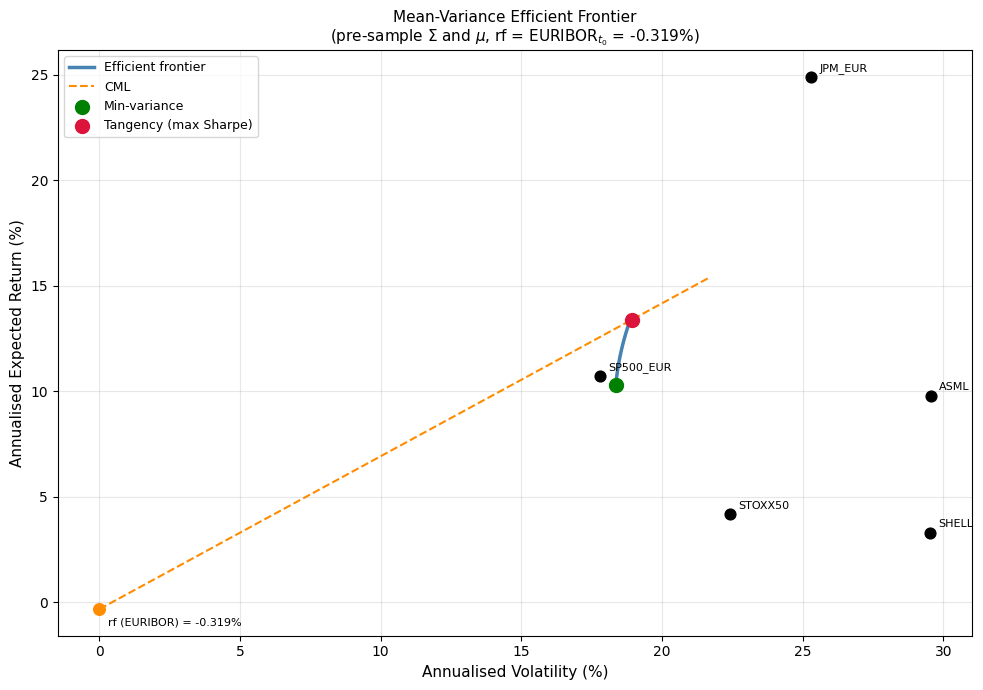

In [100]:
# Efficient frontier
targetrets = np.linspace(mu.min() * 0.8, mu.max() * 1.1, 300)
frontiervols, frontierrets = [], []

for target in targetrets:
    res = minimize(
        fun=lambda w: w @ S @ w,
        x0=x0, method="SLSQP", bounds=bounds,
        constraints=[
            {"type": "eq", "fun": lambda w: w.sum() - 1},
            {"type": "eq", "fun": lambda w, t=target: w @ mu - t},
        ],
        options={"ftol": 1e-12, "maxiter": 1000}
    )
    if res.success:
        frontiervols.append(np.sqrt(res.fun))
        frontierrets.append(target)

frontiervols = np.array(frontiervols)
frontierrets = np.array(frontierrets)

# upper (efficient) half only
ret_minvar = w_minvar @ mu
mask    = frontierrets >= ret_minvar
effvols = frontiervols[mask]
effrets = frontierrets[mask]

# CML: from rf through tangency point
vol_tan = np.sqrt(w_tangent @ S @ w_tangent)
ret_tan = w_tangent @ mu
cmlvols = np.linspace(0, effvols.max() * 1.15, 200)
cmlrets = rf + (ret_tan - rf) / vol_tan * cmlvols

# individual asset scatter (pre-sample)
assetvols = np.sqrt(np.diag(S))
assetrets = mu

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(effvols * 100, effrets * 100,
        color="steelblue", linewidth=2.5, label="Efficient frontier")
ax.plot(cmlvols * 100, cmlrets * 100,
        color="darkorange", linewidth=1.5, linestyle="--", label="CML")

ax.scatter(assetvols * 100, assetrets * 100,
           color="black", s=60, zorder=5)
for i, col in enumerate(RISKY):
    ax.annotate(col, (assetvols[i] * 100, assetrets[i] * 100),
                textcoords="offset points", xytext=(6, 4), fontsize=8)

ax.scatter(np.sqrt(w_minvar @ S @ w_minvar) * 100, ret_minvar * 100,
           color="green", s=100, zorder=6, label="Min-variance")

ax.scatter(vol_tan * 100, ret_tan * 100,
           color="crimson", s=100, zorder=6, label="Tangency (max Sharpe)")

ax.scatter(0, rf * 100, color="darkorange", s=70, zorder=6)
ax.annotate(f"rf (EURIBOR) = {rf*100:.3f}%", (0, rf * 100),
            textcoords="offset points", xytext=(6, -12), fontsize=8)

ax.set_xlabel("Annualised Volatility (%)", fontsize=11)
ax.set_ylabel("Annualised Expected Return (%)", fontsize=11)
ax.set_title(
    "Mean-Variance Efficient Frontier\n"
    r"(pre-sample $\Sigma$ and $\mu$, "
    f"rf = EURIBOR$_{{t_0}}$ = {rf*100:.3f}%)",
    fontsize=11,
)
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plots/efficientfrontier.png", dpi=150, bbox_inches="tight")
plt.show()

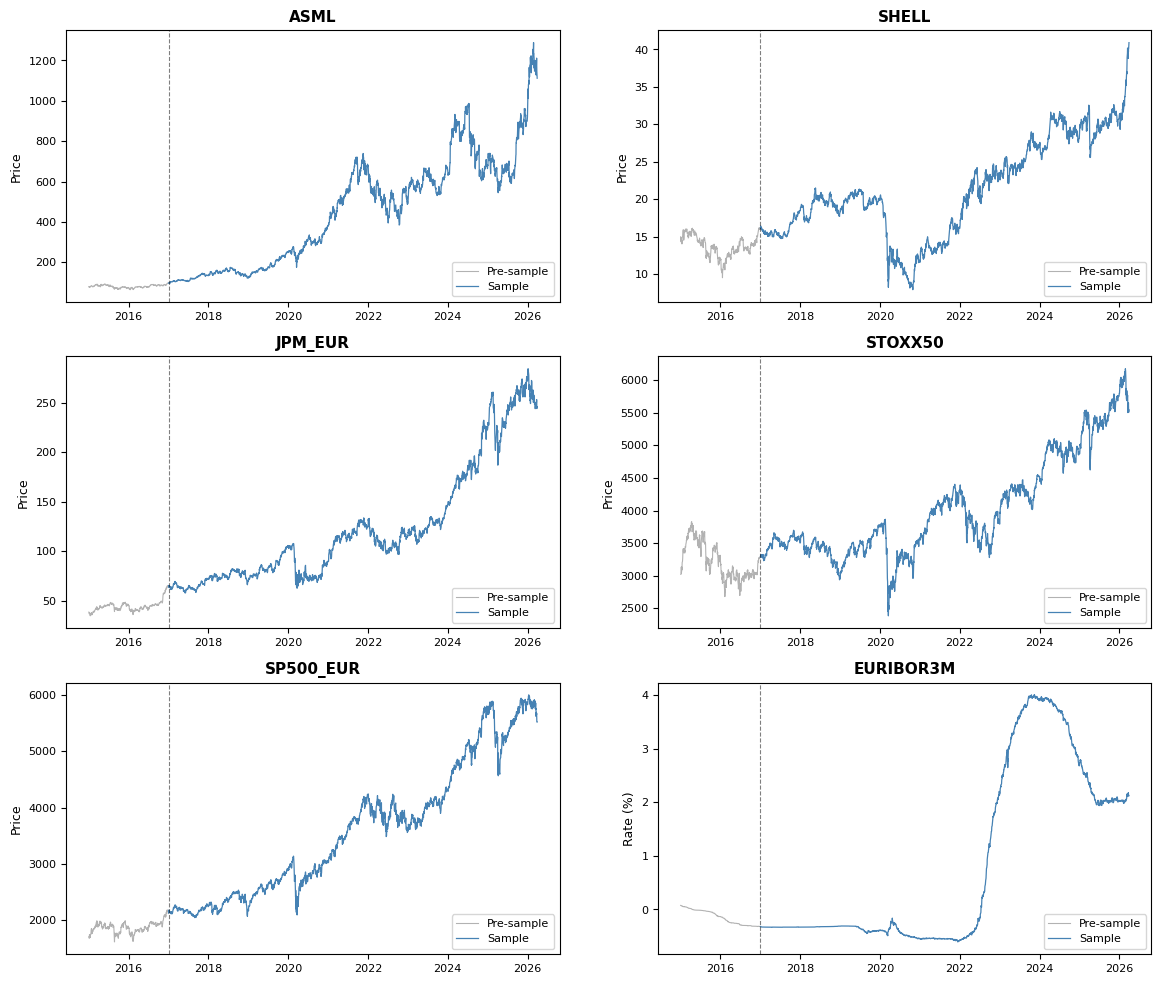

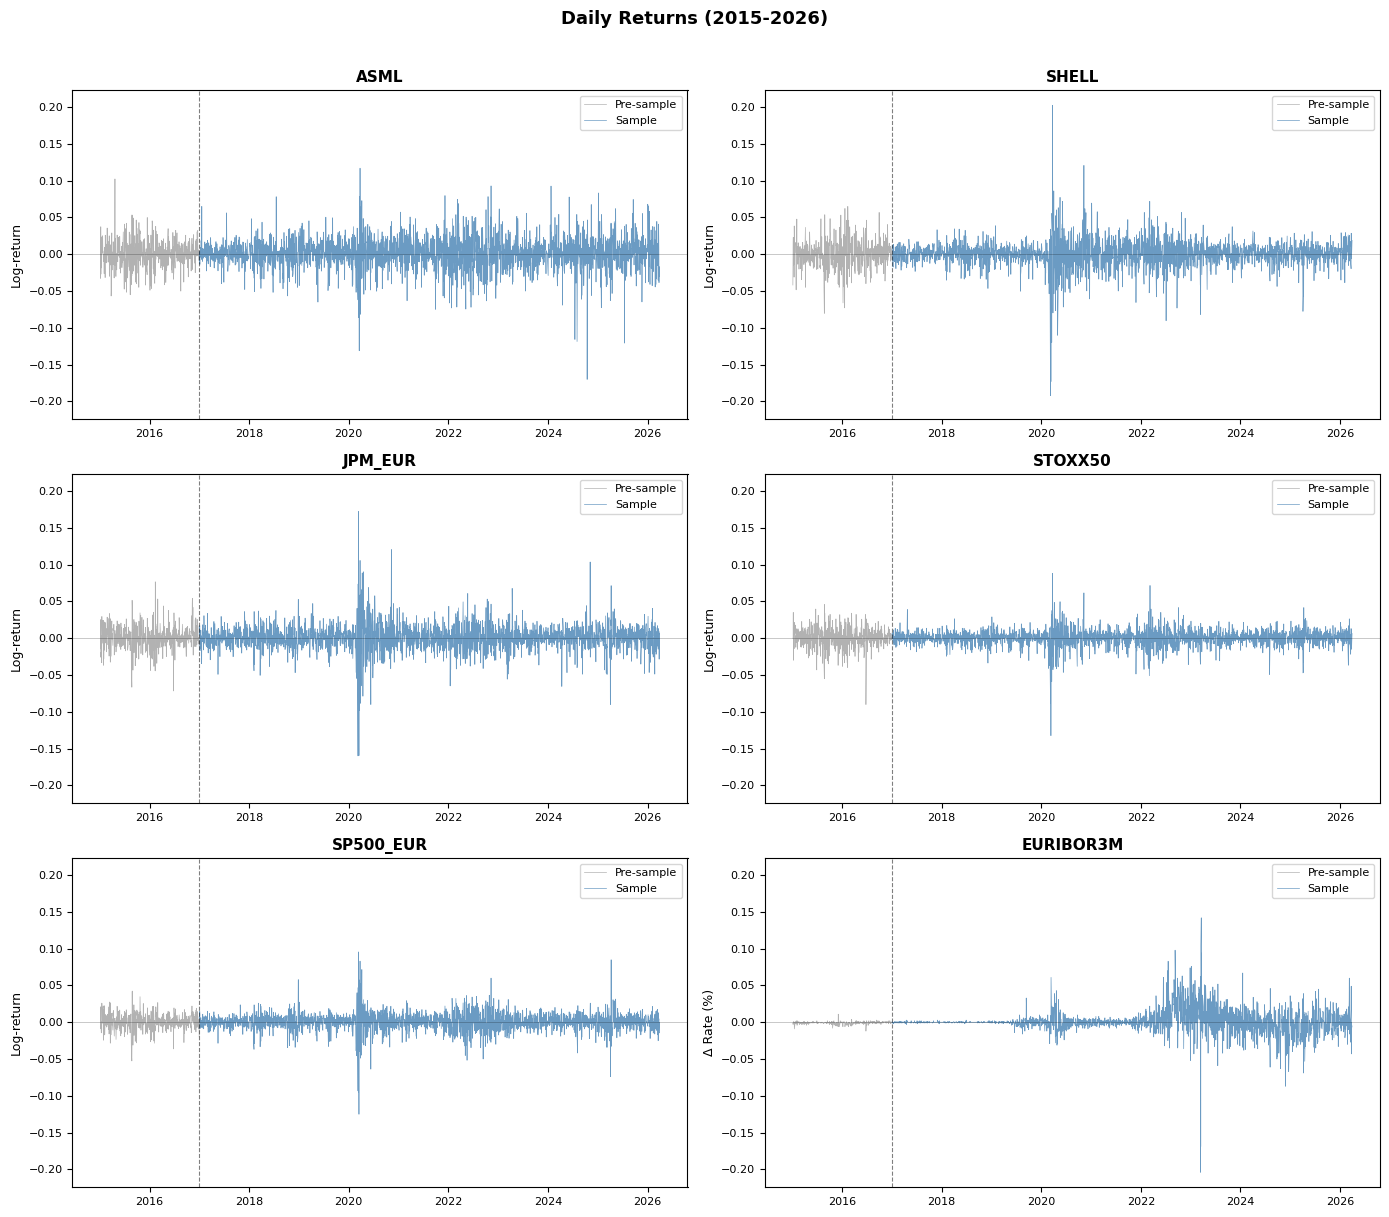

In [101]:
# Plots


# Prices (RISKY + EURIBOR)
PLOT_ASSETS = RISKY + RATE  
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(PLOT_ASSETS):
    ax = axes[i]
    ax.plot(prices_clean.loc[PRE_START:PRE_END, col],
            color="grey", linewidth=0.8, alpha=0.6, label="Pre-sample")
    ax.plot(prices_clean.loc[SAMPLE_START:SAMPLE_END, col],
            color="steelblue", linewidth=0.9, label="Sample")
    ax.axvline(pd.Timestamp(SAMPLE_START), color="black",
               linestyle="--", linewidth=0.8, alpha=0.5)
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_ylabel("Price" if col != "EURIBOR3M" else "Rate (%)", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=8)

# Returns (RISKY + EURIBOR, shared y-axis) 
all_returns = [returns.loc[PRE_START:SAMPLE_END, col].dropna() for col in PLOT_ASSETS]
global_min  = min(r.min() for r in all_returns)
global_max  = max(r.max() for r in all_returns)
pad         = (global_max - global_min) * 0.05   # 5% padding
ylim        = (global_min - pad, global_max + pad)

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(PLOT_ASSETS):
    ax = axes[i]
    ax.plot(returns.loc[PRE_START:PRE_END, col],
            color="grey", linewidth=0.5, alpha=0.6, label="Pre-sample")
    ax.plot(returns.loc[SAMPLE_START:SAMPLE_END, col],
            color="steelblue", linewidth=0.5, alpha=0.8, label="Sample")
    ax.axvline(pd.Timestamp(SAMPLE_START), color="black",
               linestyle="--", linewidth=0.8, alpha=0.5)
    ax.axhline(0, color="black", linewidth=0.5, alpha=0.3)
    ax.set_ylim(ylim)
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_ylabel("Log-return" if col != "EURIBOR3M" else "Δ Rate (%)", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=8)

plt.suptitle("Daily Returns (2015-2026)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plots/returns.png", dpi=150, bbox_inches="tight")
plt.show()

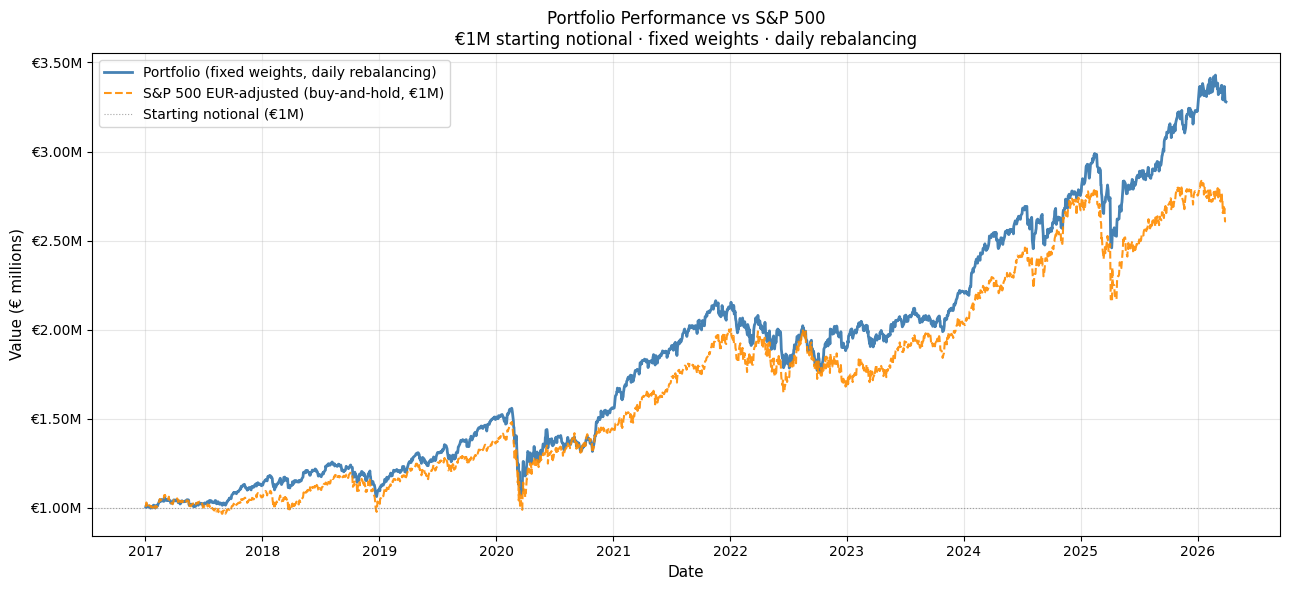

                                   Portfolio   S&P 500 EUR
Final value                        3,278,630     2,607,472
Total return                          227.9%        160.7%
Ann. return (CAGR)                     13.7%         10.9%
Ann. volatility                        15.8%         19.5%
Sharpe ratio                           0.899         0.638


In [102]:
# Portfolio Performance Over Time 

returns_plot = pd.read_csv(DATA_RETURNS, index_col=0, parse_dates=True)
returns_plot = returns_plot.loc[SAMPLE_START:SAMPLE_END]

# EUR-adjusted returns already in CSV — no manual r_USD − r_EURUSD needed

# Rebalanced portfolio (fixed weights, daily)
port_ret   = sum(WEIGHTS[a] * np.expm1(returns_plot[a]) for a in WEIGHTS)
port_value = PORTFOLIO_VALUE * (1 + pd.Series(port_ret, index=returns_plot.index)).cumprod()

# S&P 500 standalone EUR-adjusted buy-and-hold (same €1M notional)
sp500_value = PORTFOLIO_VALUE * (1 + np.expm1(returns_plot["SP500_EUR"])).cumprod()

# Plot 
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(port_value.index, port_value / 1e6,
        color="steelblue", linewidth=2.0,
        label="Portfolio (fixed weights, daily rebalancing)")
ax.plot(sp500_value.index, sp500_value / 1e6,
        color="darkorange", linewidth=1.5, linestyle="--", alpha=0.9,
        label="S&P 500 EUR-adjusted (buy-and-hold, €1M)")
ax.axhline(PORTFOLIO_VALUE / 1e6, color="grey", linewidth=0.8,
           linestyle=":", alpha=0.7, label="Starting notional (€1M)")

ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Value (€ millions)", fontsize=11)
ax.set_title(
    "Portfolio Performance vs S&P 500\n"
    f"€{PORTFOLIO_VALUE/1e6:.0f}M starting notional · fixed weights · daily rebalancing",
    fontsize=12
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x:.2f}M"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=0)
ax.legend(fontsize=10, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plots/portfolio_performance.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary stats
n_years         = (pd.Timestamp(SAMPLE_END) - pd.Timestamp(SAMPLE_START)).days / 365.25
total_ret_port  = (port_value.iloc[-1]  / PORTFOLIO_VALUE - 1) * 100
total_ret_sp500 = (sp500_value.iloc[-1] / PORTFOLIO_VALUE - 1) * 100

port_daily_ret  = pd.Series(port_ret, index=returns_plot.index)
sp500_daily_ret = np.expm1(returns_plot["SP500_EUR"])

rf_daily     = EURIBOR_T0 / 100 / TRADING_DAYS
sharpe_port  = (port_daily_ret.mean()  - rf_daily) / port_daily_ret.std()  * np.sqrt(TRADING_DAYS)
sharpe_sp500 = (sp500_daily_ret.mean() - rf_daily) / sp500_daily_ret.std() * np.sqrt(TRADING_DAYS)

print(f"{'':30s}  {'Portfolio':>12}  {'S&P 500 EUR':>12}")
print(f"{'Final value':30s}  {port_value.iloc[-1]:>12,.0f}  {sp500_value.iloc[-1]:>12,.0f}")
print(f"{'Total return':30s}  {total_ret_port:>11.1f}%  {total_ret_sp500:>11.1f}%")
print(f"{'Ann. return (CAGR)':30s}  "
      f"{((1+total_ret_port/100)**(1/n_years)-1)*100:>11.1f}%  "
      f"{((1+total_ret_sp500/100)**(1/n_years)-1)*100:>11.1f}%")
print(f"{'Ann. volatility':30s}  "
      f"{port_daily_ret.std()  * np.sqrt(TRADING_DAYS) * 100:>11.1f}%  "
      f"{sp500_daily_ret.std() * np.sqrt(TRADING_DAYS) * 100:>11.1f}%")
print(f"{'Sharpe ratio':30s}  {sharpe_port:>12.3f}  {sharpe_sp500:>12.3f}")

In [103]:
print(prices_clean.head())
print(returns.head())  

# Quick sanity check 
r = np.log(prices_clean["ASML"] / prices_clean["ASML"].shift(1)).dropna()
r_pre = r.loc[PRE_START:PRE_END]
print(f"ASML daily vol (pre-sample): {r_pre.std():.5f}")
print(f"ASML annualised (pre-sample): {r_pre.std() * np.sqrt(252) * 100:.2f}%")

                 ASML      SHELL        JPM      STOXX50        SP500  \
Date                                                                    
2015-01-02  79.890160  14.977293  46.274311  3023.139893  2058.199951   
2015-01-05  78.420197  14.364708  44.837723  3023.139893  2020.579956   
2015-01-06  75.892525  14.310737  43.675129  3023.139893  2002.609985   
2015-01-07  76.143501  14.502336  43.741779  3026.790039  2025.900024   
2015-01-08  79.047638  14.839665  44.719250  3135.080078  2062.139893   

              EURUSD  EURIBOR3M    JPM_EUR    SP500_EUR  
Date                                                     
2015-01-02  1.208941      0.076  38.276722  1702.481239  
2015-01-05  1.194643      0.075  37.532311  1691.366808  
2015-01-06  1.193902      0.073  36.581852  1677.366115  
2015-01-07  1.187536      0.070  36.834077  1705.969867  
2015-01-08  1.183600      0.070  37.782399  1742.260708  
                ASML     SHELL       JPM   STOXX50     SP500    EURUSD  \
Date    

## **Tasks 3: Methods 1 (HS) & 2 (Variance–Covariance)**

In [104]:
DATA_RETURNS = Path("data/returns_clean.csv")
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

PRE_START    = "2015-01-01"
PRE_END      = "2016-12-31"
SAMPLE_START = "2017-01-01"
SAMPLE_END   = "2026-03-31"
TRADING_DAYS = 252
PORTFOLIO_VALUE = 1_000_000
ALPHAS = [0.01, 0.05]
DF_CANDIDATES = [3, 4, 5, 6]
BACKTEST_ALPHA = 0.01

WEIGHTS = {
    "ASML": 0.16,
    "SHELL": 0.08,
    "JPM_EUR": 0.24,
    "STOXX50": 0.08,
    "SP500_EUR": 0.24,
    "LOAN": 0.20,
}
MODEL_ASSETS = list(WEIGHTS)
WEIGHT_VECTOR = pd.Series(WEIGHTS)[MODEL_ASSETS]


In [105]:
raw_returns = pd.read_csv(DATA_RETURNS, index_col=0, parse_dates=True).sort_index()

simple_returns = pd.DataFrame(index=raw_returns.index)
for col in MODEL_ASSETS:
    simple_returns[col] = raw_returns[col] if col == "LOAN" else np.expm1(raw_returns[col])

ret_pre = simple_returns.loc[PRE_START:PRE_END, MODEL_ASSETS].dropna()
ret_sample = simple_returns.loc[SAMPLE_START:SAMPLE_END, MODEL_ASSETS].dropna()

assert abs(WEIGHT_VECTOR.sum() - 1.0) < 1e-10
assert len(ret_pre) > 0 and len(ret_sample) > 0

summary = pd.DataFrame({"weight": WEIGHT_VECTOR, "notional_eur": WEIGHT_VECTOR * PORTFOLIO_VALUE})
print(f"Pre-sample: {ret_pre.index.min().date()} → {ret_pre.index.max().date()} | {len(ret_pre)} obs")
print(f"Sample   : {ret_sample.index.min().date()} → {ret_sample.index.max().date()} | {len(ret_sample)} obs")
display(summary)


Pre-sample: 2015-01-05 → 2016-12-30 | 512 obs
Sample   : 2017-01-02 → 2026-03-30 | 2366 obs


,weight,notional_eur
ASML,0.16,160000.0
SHELL,0.08,80000.0
JPM_EUR,0.24,240000.0
STOXX50,0.08,80000.0
SP500_EUR,0.24,240000.0
LOAN,0.20,200000.0


In [106]:
def portfolio_moments(weights, mu_vec, cov_mat):
    w = np.asarray(weights, dtype=float)
    mu_p = float(w @ mu_vec)
    sigma_p = float(np.sqrt(w @ cov_mat @ w))
    return mu_p, sigma_p


def normal_var_es(mu, sigma, alpha, notional):
    z = norm.ppf(alpha)
    var = notional * (-mu - sigma * z)
    es = notional * (-mu + sigma * norm.pdf(z) / alpha)
    return var, es


def student_t_var_es(mu, sigma, alpha, nu, notional):
    scale = sigma * np.sqrt((nu - 2) / nu)
    q = t.ppf(alpha, df=nu)
    pdf_q = t.pdf(q, df=nu)
    var = notional * (-mu - scale * q)
    es = notional * (-mu + scale * ((nu + q**2) / ((nu - 1) * alpha)) * pdf_q)
    return var, es


def pooled_standardised_residuals(sample):
    z = (sample - sample.mean()) / sample.std(ddof=1)
    return z.stack().dropna().to_numpy()


def unit_variance_t_quantiles(n, nu):
    probs = (np.arange(1, n + 1) - 0.5) / n
    return np.sqrt((nu - 2) / nu) * t.ppf(probs, df=nu)


def qq_rmse(z_values, nu):
    empirical = np.sort(z_values)
    theoretical = unit_variance_t_quantiles(len(empirical), nu)
    return float(np.sqrt(np.mean((empirical - theoretical) ** 2)))


**Choose Student-t df**

Selected df: 5


,df,qq_rmse
2,5,0.054432
3,6,0.071716
1,4,0.074996
0,3,0.187679


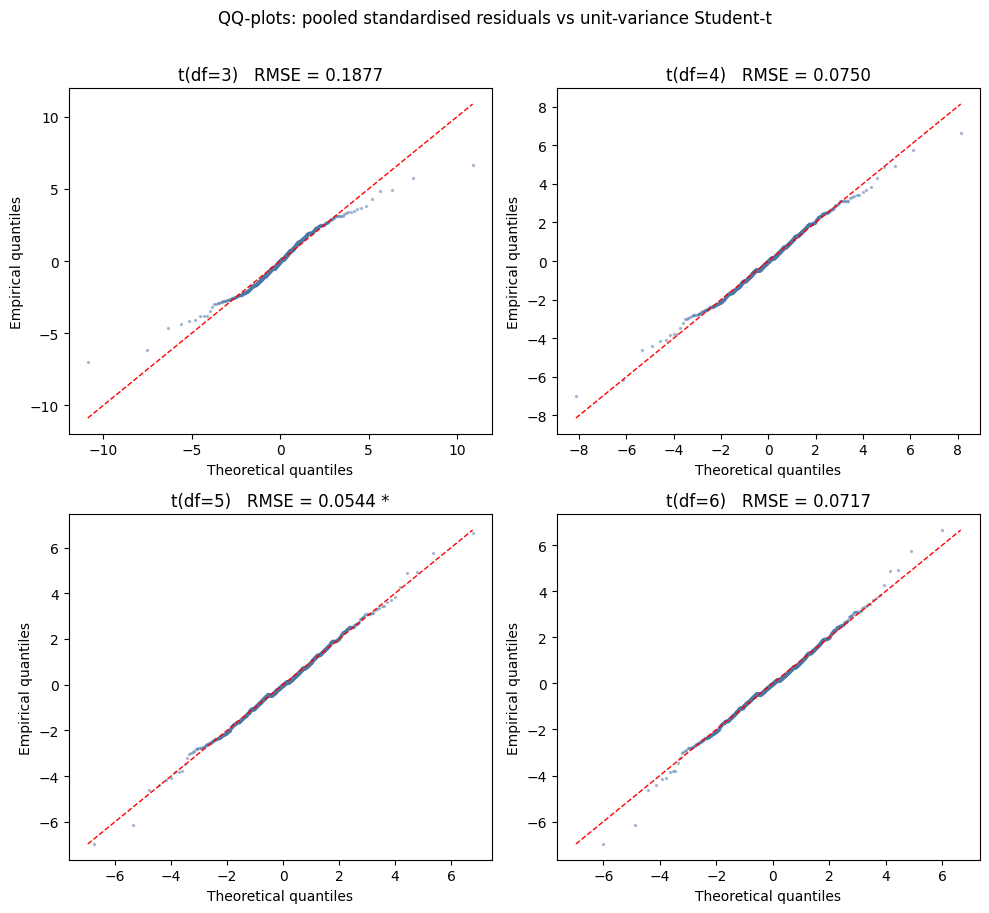

In [107]:
z_pre = pooled_standardised_residuals(ret_pre)
qq_rows = []
for nu in DF_CANDIDATES:
    qq_rows.append({"df": nu, "qq_rmse": qq_rmse(z_pre, nu)})
qq_summary = pd.DataFrame(qq_rows).sort_values("qq_rmse")
BEST_DF = int(qq_summary.iloc[0]["df"])
print(f"Selected df: {BEST_DF}")
display(qq_summary)


z_sorted = np.sort(z_pre)
n = len(z_sorted)

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.ravel()

for idx, nu in enumerate(DF_CANDIDATES):
    ax = axes[idx]
    theoretical = unit_variance_t_quantiles(n, nu)
    ax.scatter(theoretical, z_sorted, s=2, alpha=0.4, color="#4c78a8")
    lims = [min(theoretical.min(), z_sorted.min()), max(theoretical.max(), z_sorted.max())]
    ax.plot(lims, lims, "r--", linewidth=1)
    rmse = qq_rmse(z_pre, nu)
    ax.set_title(f"t(df={nu})   RMSE = {rmse:.4f}"
                 + (" *" if nu == BEST_DF else ""))
    ax.set_xlabel("Theoretical quantiles")
    ax.set_ylabel("Empirical quantiles")

plt.suptitle("QQ-plots: pooled standardised residuals vs unit-variance Student-t",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "01_qq_plots.png", dpi=150, bbox_inches="tight")
plt.show()




**Normal**
**Student-t**

In [108]:
def risk_table(sample, model_name, alphas, nu=None):
    mu = sample.mean()
    cov = sample.cov()
    rows = []

    for asset, weight in WEIGHTS.items():
        notional = weight * PORTFOLIO_VALUE
        mu_i = float(mu[asset])
        sigma_i = float(np.sqrt(cov.loc[asset, asset]))

        for alpha in alphas:
            if nu is None:
                var_i, es_i = normal_var_es(mu_i, sigma_i, alpha, notional)
            else:
                var_i, es_i = student_t_var_es(mu_i, sigma_i, alpha, nu, notional)
            rows.append({
                "model": model_name,
                "alpha": alpha,
                "entity": asset,
                "VaR_eur": var_i,
                "ES_eur": es_i,
            })

    mu_p, sigma_p = portfolio_moments(WEIGHT_VECTOR.values, mu.values, cov.values)
    for alpha in alphas:
        if nu is None:
            var_p, es_p = normal_var_es(mu_p, sigma_p, alpha, PORTFOLIO_VALUE)
        else:
            var_p, es_p = student_t_var_es(mu_p, sigma_p, alpha, nu, PORTFOLIO_VALUE)
        rows.append({"model": model_name, "alpha": alpha, "entity": "Portfolio", "VaR_eur": var_p, "ES_eur": es_p})

    return pd.DataFrame(rows)

risk_normal = risk_table(ret_sample, "Normal", ALPHAS)
risk_t = risk_table(ret_sample, f"Student-t df={BEST_DF}", ALPHAS, nu=BEST_DF)

for label, df in [("Normal", risk_normal), ("Student-t", risk_t)]:
    print(f"\n{label} VaR/ES")
    display(df.sort_values(["alpha", "entity"]).pivot(index="entity", columns="alpha", values=["VaR_eur", "ES_eur"]).round(0))



Normal VaR/ES


VaR_eur            ES_eur         
alpha         0.01     0.05     0.01     0.05
entity                                       
ASML        7854.0   5494.0   9028.0   6941.0
JPM_EUR     9842.0   6907.0  11301.0   8707.0
LOAN         679.0    483.0    777.0    603.0
Portfolio  22621.0  15833.0  25996.0  19995.0
SHELL       3296.0   2317.0   3782.0   2917.0
SP500_EUR   6745.0   4736.0   7745.0   5968.0
STOXX50     2082.0   1465.0   2388.0   1843.0


Student-t VaR/ES


VaR_eur            ES_eur         
alpha         0.01     0.05     0.01     0.05
entity                                       
ASML        8824.0   5203.0  11741.0   7550.0
JPM_EUR    11048.0   6545.0  14675.0   9464.0
LOAN         760.0    459.0   1002.0    654.0
Portfolio  25411.0  14996.0  33802.0  21748.0
SHELL       3698.0   2197.0   4908.0   3170.0
SP500_EUR   7572.0   4488.0  10056.0   6487.0
STOXX50     2335.0   1389.0   3097.0   2002.0

**Backtest**
Expanding window VaR backtest on portfolio for Normal vs Student-t.

In [109]:
def expanding_backtest(sample_all, alpha, nu=None, min_obs=250):
    out = []
    sample_dates = sample_all.loc[SAMPLE_START:SAMPLE_END].index

    for date in sample_dates:
        history = sample_all.loc[sample_all.index < date, MODEL_ASSETS].dropna()
        if len(history) < min_obs:
            continue

        mu = history.mean().values
        cov = history.cov().values
        mu_p, sigma_p = portfolio_moments(WEIGHT_VECTOR.values, mu, cov)

        if nu is None:
            var_t, es_t = normal_var_es(mu_p, sigma_p, alpha, PORTFOLIO_VALUE)
        else:
            var_t, es_t = student_t_var_es(mu_p, sigma_p, alpha, nu, PORTFOLIO_VALUE)

        realised_return = float(WEIGHT_VECTOR.values @ sample_all.loc[date, MODEL_ASSETS].values)
        realised_loss = -PORTFOLIO_VALUE * realised_return

        out.append({"date": date, "VaR_eur": var_t, "ES_eur": es_t, "loss_eur": realised_loss})

    bt = pd.DataFrame(out).set_index("date")
    bt["hit"] = bt["loss_eur"] > bt["VaR_eur"]
    return bt

bt_normal = expanding_backtest(simple_returns, alpha=BACKTEST_ALPHA)
bt_t = expanding_backtest(simple_returns, alpha=BACKTEST_ALPHA, nu=BEST_DF)


def summarize(bt):
    return pd.Series({
        "obs": len(bt),
        "hits": bt["hit"].sum(),
        "hit_rate": bt["hit"].mean(),
        "avg_VaR_on_hits": bt.loc[bt["hit"], "VaR_eur"].mean(),
        "avg_shortfall": bt.loc[bt["hit"], "loss_eur"].mean(),
    })

summary = pd.concat({"Normal": summarize(bt_normal), f"Student-t df={BEST_DF}": summarize(bt_t)}, axis=1)
print(f"Backtest alpha = {BACKTEST_ALPHA:.0%}")
display(summary.T)


Backtest alpha = 1%


,obs,hits,hit_rate,avg_VaR_on_hits,avg_shortfall
Normal,2366.0,46.0,0.019442,21200.663303,32944.440959
Student-t df=5,2366.0,33.0,0.013948,23789.903430,36995.693474


**Plots**
Loss vs VaR and rolling violation counts

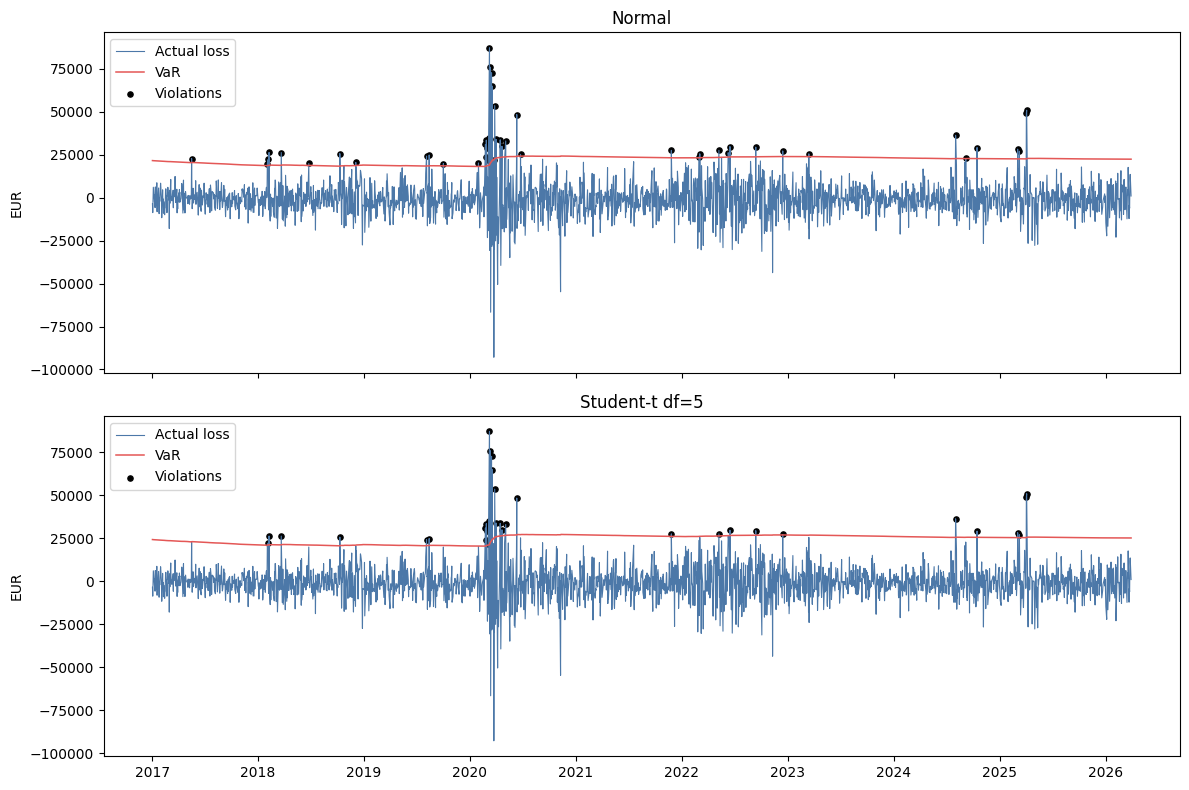

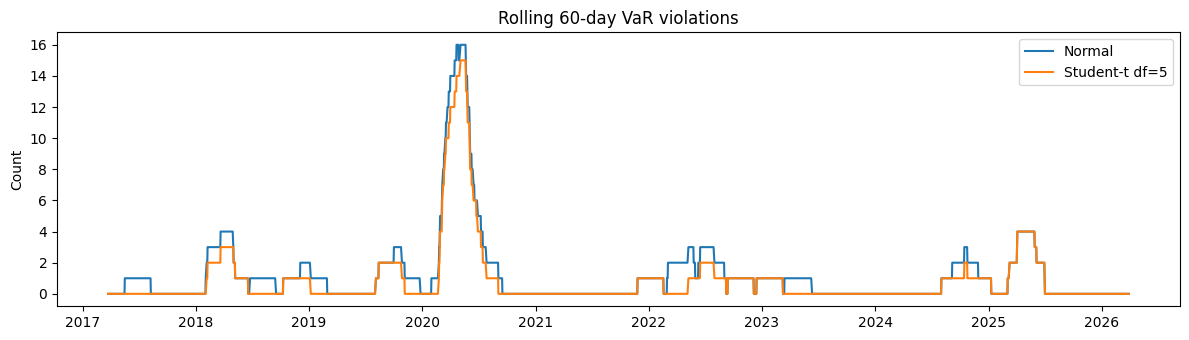

In [110]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for ax, bt, title in [
    (axes[0], bt_normal, "Normal"),
    (axes[1], bt_t, f"Student-t df={BEST_DF}"),
]:
    ax.plot(bt.index, bt["loss_eur"], color="#4c78a8", linewidth=0.8, label="Actual loss")
    ax.plot(bt.index, bt["VaR_eur"], color="#e45756", linewidth=1.1, label="VaR")
    ax.scatter(bt.index[bt["hit"]], bt.loc[bt["hit"], "loss_eur"], color="black", s=14, label="Violations")
    ax.set_title(title)
    ax.set_ylabel("EUR")
    ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "02_backtest_loss_vs_var.png", dpi=150, bbox_inches="tight")
plt.show()

rolling_window = 60
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(bt_normal.index, bt_normal["hit"].rolling(rolling_window).sum(), label="Normal")
ax.plot(bt_t.index, bt_t["hit"].rolling(rolling_window).sum(), label=f"Student-t df={BEST_DF}")
ax.set_title(f"Rolling {rolling_window}-day VaR violations")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "02_backtest_rolling_hits.png", dpi=150, bbox_inches="tight")
plt.show()


In [111]:
# ── Yearly violation count vs expected ──────────────────────────────────────
for label, bt in [("Normal", bt_normal), (f"Student-t df={BEST_DF}", bt_t)]:
    yearly = bt.groupby(bt.index.year)["hit"].agg(["sum", "count"])
    yearly.columns = ["violations", "trading_days"]
    yearly["expected"] = yearly["trading_days"] * BACKTEST_ALPHA
    print(f"\n{label} — yearly violations")
    display(yearly)

# ── Average ES vs actual average shortfall on violation days ────────────────
for label, bt in [("Normal", bt_normal), (f"Student-t df={BEST_DF}", bt_t)]:
    hits = bt.loc[bt["hit"]]
    print(f"\n{label} — ES vs realised shortfall on violation days")
    print(f"  Avg predicted ES : {hits['ES_eur'].mean():,.0f}")
    print(f"  Avg realised loss: {hits['loss_eur'].mean():,.0f}")

# ── Sample sensitivity: pre-2025 vs full sample ────────────────────────────
ret_pre2025 = ret_sample.loc[:"2024-12-31"]
for label, sample in [("Up to 2024/12", ret_pre2025), ("Full (to 2026/3)", ret_sample)]:
    mu_p, sigma_p = portfolio_moments(
        WEIGHT_VECTOR.values, sample.mean().values, sample.cov().values)
    var_n, es_n = normal_var_es(mu_p, sigma_p, 0.01, PORTFOLIO_VALUE)
    var_t, es_t = student_t_var_es(mu_p, sigma_p, 0.01, BEST_DF, PORTFOLIO_VALUE)
    print(f"{label:25s}  n={len(sample):4d}  "
          f"VaR_N={var_n:,.0f}  ES_N={es_n:,.0f}  "
          f"VaR_t={var_t:,.0f}  ES_t={es_t:,.0f}")


Normal — yearly violations


,violations,trading_days,expected
date,,,
2017,1,256,2.56
2018,7,255,2.55
2019,3,255,2.55
2020,19,257,2.57
2021,1,258,2.58
2022,7,257,2.57
2023,1,255,2.55
2024,3,256,2.56
2025,4,255,2.55



Student-t df=5 — yearly violations


,violations,trading_days,expected
date,,,
2017,0,256,2.56
2018,4,255,2.55
2019,2,255,2.55
2020,16,257,2.57
2021,1,258,2.58
2022,4,257,2.57
2023,0,255,2.55
2024,2,256,2.56
2025,4,255,2.55



Normal — ES vs realised shortfall on violation days
  Avg predicted ES : 24,361
  Avg realised loss: 32,944

Student-t df=5 — ES vs realised shortfall on violation days
  Avg predicted ES : 31,636
  Avg realised loss: 36,996
Up to 2024/12              n=2049  VaR_N=22,924  ES_N=26,342  VaR_t=25,750  ES_t=34,248
Full (to 2026/3)           n=2366  VaR_N=22,621  ES_N=25,996  VaR_t=25,411  ES_t=33,802


In [112]:
for label, bt in [("Normal", bt_normal), (f"Student-t df={BEST_DF}", bt_t)]:
    hits = bt.loc[bt["hit"]]
    yearly_es = hits.groupby(hits.index.year).agg(
        avg_predicted_ES=("ES_eur", "mean"),
        avg_realised_loss=("loss_eur", "mean"),
        n_violations=("hit", "count"),
    ).round(0)
    print(f"\n{label} — yearly ES vs realised shortfall")
    display(yearly_es)


Normal — yearly ES vs realised shortfall


,avg_predicted_ES,avg_realised_loss,n_violations
date,,,
2017,23459.0,22816.0,1
2018,21507.0,23015.0,7
2019,21241.0,23014.0,3
2020,24026.0,40824.0,19
2021,26633.0,27594.0,1
2022,27106.0,27100.0,7
2023,27443.0,25559.0,1
2024,26164.0,29477.0,3
2025,26015.0,38886.0,4



Student-t df=5 — yearly ES vs realised shortfall


,avg_predicted_ES,avg_realised_loss,n_violations
date,,,
2018,27978.0,25185.0,4
2019,27624.0,24560.0,2
2020,31072.0,44259.0,16
2021,34649.0,27594.0,1
2022,35441.0,28532.0,4
2024,33995.0,32795.0,2
2025,33821.0,38886.0,4


## **Tasks 4: Method 4 (GARCH)**

In [113]:
# Data paths
DATA_RAW     = "data/data_real.xlsx"
DATA_PRICES  = "data/prices_clean.csv"
DATA_RETURNS = "data/returns_clean.csv"

# ── Time periods ──────────────────────────────────────────────────────────────
PRE_START    = "2015-01-01"
PRE_END      = "2016-12-31"
SAMPLE_START = "2017-01-01"
SAMPLE_END   = "2026-03-31"

# ── Portfolio ─────────────────────────────────────────────────────────────────
PORTFOLIO_VALUE = 1000000
LOAN_WEIGHT     = 0.20        # two-fund split: 20% bond, 80% tangency portfolio
RISKY_WEIGHT    = 0.80
WEIGHT_MIN      = 0.10
WEIGHT_MAX      = 0.30
LOAN_SPREAD_BPS = 150
TRADING_DAYS    = 252

# ── Asset lists ───────────────────────────────────────────────────────────────
STOCKS_USD = ["ASML", "SHELL", "JPM"]
INDEX_USD  = ["STOXX50", "SP500"]
RISKY_USD  = STOCKS_USD + INDEX_USD

STOCKS = ["ASML", "SHELL", "JPM_EUR"]
INDEX  = ["STOXX50", "SP500_EUR"]
RISKY  = STOCKS + INDEX

FX       = ["EURUSD"]
RATE     = ["EURIBOR3M"]
ALL_COLS = STOCKS_USD + INDEX_USD + FX + RATE   # ← only once, after FX/RATE defined

# NOTE: JPM_EUR and SP500_EUR in DATA_RETURNS are EUR-adjusted log-returns
#       (r_USD - r_EURUSD). Use RISKY for VaR/ES/portfolio P&L.
#       Use RISKY_USD vs RISKY for FX risk decomposition.


# ── Populated after running Section 4 — paste output back in ─────────────────
EURIBOR_T0    = -0.319000
LOAN_COUPON   = 0.011810
LOAN_MATURITY = 9.242984
LOAN_MOD_DUR  = 9.135099   # fixed-rate duration
WEIGHTS = {
    "ASML": 0.160000,
    "SHELL": 0.080000,
    "JPM_EUR": 0.240000,
    "STOXX50": 0.080000,
    "SP500_EUR": 0.240000,
    "LOAN": 0.200000,
}


assets = ['SHELL','ASML','JPM_EUR','STOXX50','SP500_EUR','LOAN']
ASSET_WEALTH = {asset : WEIGHTS[asset]*PORTFOLIO_VALUE for asset in assets}

In [114]:
risky_returns = pd.read_csv(DATA_RETURNS)

in_sample_returns = risky_returns[(risky_returns['Date']>=SAMPLE_START) ].copy()


ret_SHELL = in_sample_returns[['Date','SHELL']]
ret_ASML = in_sample_returns[['Date','ASML']]
ret_JPM = in_sample_returns[['Date','JPM_EUR']]
ret_STOXX50 = in_sample_returns[['Date','STOXX50']]
ret_SP500 = in_sample_returns[['Date','SP500_EUR']]
ret_LOAN = in_sample_returns[['Date','LOAN']]


In [115]:
in_sample_returns.head()

,Date,ASML,SHELL,JPM,STOXX50,SP500,EURUSD,EURIBOR3M,JPM_EUR,SP500_EUR,LOAN
512,2017-01-02,0.003743,0.009003,0.000000,0.000000,0.000000,-0.004579,0.001,0.004579,0.004579,-0.000044
513,2017-01-03,-0.004212,0.011942,0.010835,0.007418,0.008451,-0.006380,-0.001,0.017215,0.014831,0.000138
514,2017-01-04,-0.013696,0.004887,0.001843,0.000754,0.005706,-0.003842,-0.001,0.005685,0.009548,0.000138
515,2017-01-05,0.002375,-0.005076,-0.009248,-0.000317,-0.000771,0.007741,-0.001,-0.016988,-0.008512,0.000138
516,2017-01-06,0.000000,-0.003966,0.000117,0.001416,0.003511,0.009952,0.000,-0.009835,-0.006441,0.000047


In [116]:
mu_SHELL = ret_SHELL['SHELL'].mean()
mu_ASML = ret_ASML['ASML'].mean()
mu_JPM_EUR = ret_JPM['JPM_EUR'].mean()
mu_STOXX50 = ret_STOXX50['STOXX50'].mean()
mu_SP500_EUR = ret_SP500['SP500_EUR'].mean()
mu_LOAN = ret_LOAN['LOAN'].mean()

mu = {
    'ASML': mu_ASML,
    'SHELL': mu_SHELL,
    'JPM_EUR': mu_JPM_EUR,
    'STOXX50': mu_STOXX50,
    'SP500_EUR': mu_SP500_EUR,
    'LOAN': mu_LOAN
}

**Innovation calculation**

In [117]:

innovations = {}

for asset in assets:

    innovations[asset] = in_sample_returns[['Date', asset]].copy()
    innovations[asset][asset] = innovations[asset][asset] - innovations[asset][asset].mean()



**CCC GARCH(1,1) fitting: for each element**

In [118]:
volatility_process = {}
forecasted_vol_process = {}


for asset in assets:
    innovation_series = innovations[asset][asset]

    model = arch_model(innovation_series, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')

    volatility_process[asset] = pd.DataFrame({
        'Date': innovations[asset]['Date'],
        'Volatility': res.conditional_volatility
    })

    params = res.params
    omega = params[0]
    alpha = params[1]
    beta = params[2]


    sigma_last = res.conditional_volatility.iloc[-1]
    forecasted_vol_process[asset] = []


    a = innovations[asset].iloc[-1][asset]
    sigma_next = np.sqrt(omega + alpha * a**2 + beta * sigma_last**2)
    forecasted_vol_process[asset].append(sigma_next)


    forecasted_vol_process[asset] = pd.DataFrame({
    'Date': 'Next Day',
    'Volatility': forecasted_vol_process[asset]
    })

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/arch/univariate/base.py:768: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(


In [119]:

dates = volatility_process['SHELL']['Date'].copy()
n_obs = len(dates)

n_assets = len(assets)
n_obs_out = 1
Delta = np.zeros((n_obs, n_assets, n_assets))
Delta_hat_next = np.zeros((n_obs_out, n_assets, n_assets))

for i, asset in enumerate(assets):
    Delta[:, i, i] = pd.array(volatility_process[asset]['Volatility'].values)
    Delta_hat_next[:, i, i] = pd.array(forecasted_vol_process[asset]['Volatility'].values)




In [120]:
Devol_innovations = {}
for asset in assets:

    Devol_innovations[asset] = innovations[asset].copy()
    Devol_innovations[asset][asset] = innovations[asset][asset]/volatility_process[asset]['Volatility'].values


In [121]:
Y = pd.DataFrame({
    asset: Devol_innovations[asset][asset].values
    for asset in assets
})

P = Y.corr()



In [122]:
Sigmas = np.zeros((n_obs, n_assets, n_assets))
for i in range(len(dates)):
    Sigmas[i] = Delta[i]@P@Delta[i]

In [123]:
Sigmas_predicted = np.zeros((n_obs_out, n_assets, n_assets))

Sigmas_predicted[0] = Delta_hat_next[0]@P@Delta_hat_next[0]

In [124]:
Sigmas_dict = {
    dates.iloc[t]: Sigmas[t]
    for t in range(len(dates))
}

**Conditional 95% 1-day VAR and ES for the elements and for portfolio**

In [125]:
alpha = 0.99
z = norm.ppf(alpha)
print(z)
phi_z = norm.pdf(z)
VAR_95_predicted = {}
ES_95_predicted = {}


for i, asset in enumerate(assets):
    sigma_hat_it = np.sqrt(Sigmas_predicted[0][i, i])
    VAR_95_predicted[asset] = ASSET_WEALTH[asset]*(-mu[asset] + z * sigma_hat_it)
    ES_95_predicted[asset] = ASSET_WEALTH[asset]*(mu[asset] + sigma_hat_it * phi_z / (1 - alpha))



2.3263478740408408


In [126]:
VAR_95_predicted

{'SHELL': np.float64(2905.3255666818527),
 'ASML': np.float64(8856.869440809101),
 'JPM_EUR': np.float64(7993.550389727221),
 'STOXX50': np.float64(2102.2617906255814),
 'SP500_EUR': np.float64(6512.867543639313),
 'LOAN': np.float64(942.8663454593757)}

In [127]:
ES_95_predicted

{'SHELL': np.float64(3396.5796322849956),
 'ASML': np.float64(10500.221558285326),
 'JPM_EUR': np.float64(9452.460739867045),
 'STOXX50': np.float64(2446.3049944522227),
 'SP500_EUR': np.float64(7670.152725500009),
 'LOAN': np.float64(1059.8754942405653)}

**Conditional historical 95% 1-day VAR and ES for the elements**

In [128]:

VAR_95 = pd.DataFrame(index=Sigmas_dict.keys(), columns=assets)

for date, Sigma_hat_t in Sigmas_dict.items():
    for i, asset in enumerate(assets):
        sigma_hat_it = np.sqrt(Sigma_hat_t[i, i])  # volatility
        VAR_95.loc[date, asset] = ASSET_WEALTH[asset]*(-mu[asset] + z * sigma_hat_it)



In [129]:

phi_z = norm.pdf(z)
ES_95 = pd.DataFrame(index=Sigmas_dict.keys(), columns=assets)

for date, Sigma_hat_t in Sigmas_dict.items():
    for i, asset in enumerate(assets):
        sigma_hat_it = np.sqrt(Sigma_hat_t[i, i])
        ES_95.loc[date, asset] = (mu[asset] + sigma_hat_it * phi_z / (1 - alpha))*ASSET_WEALTH[asset]




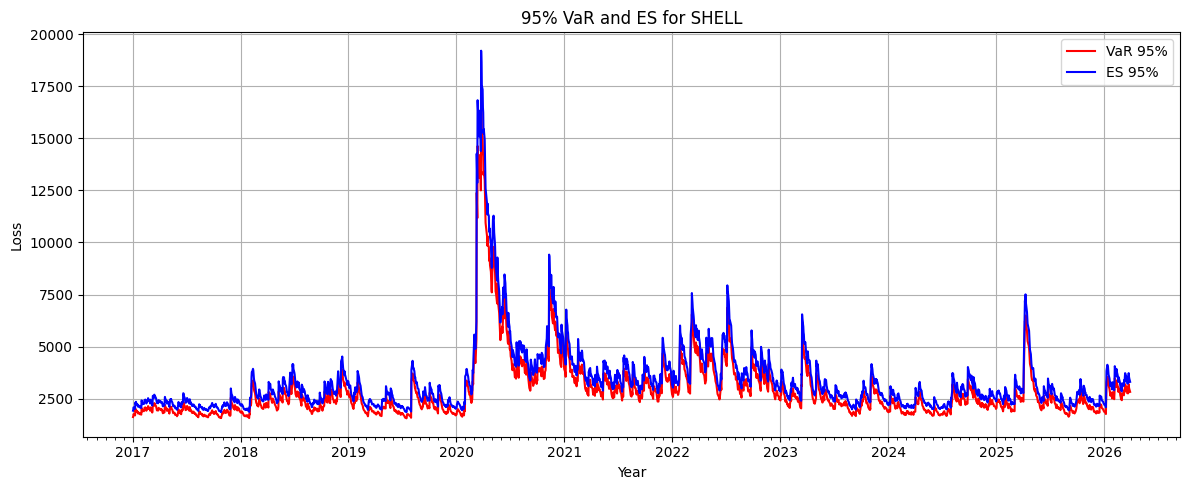

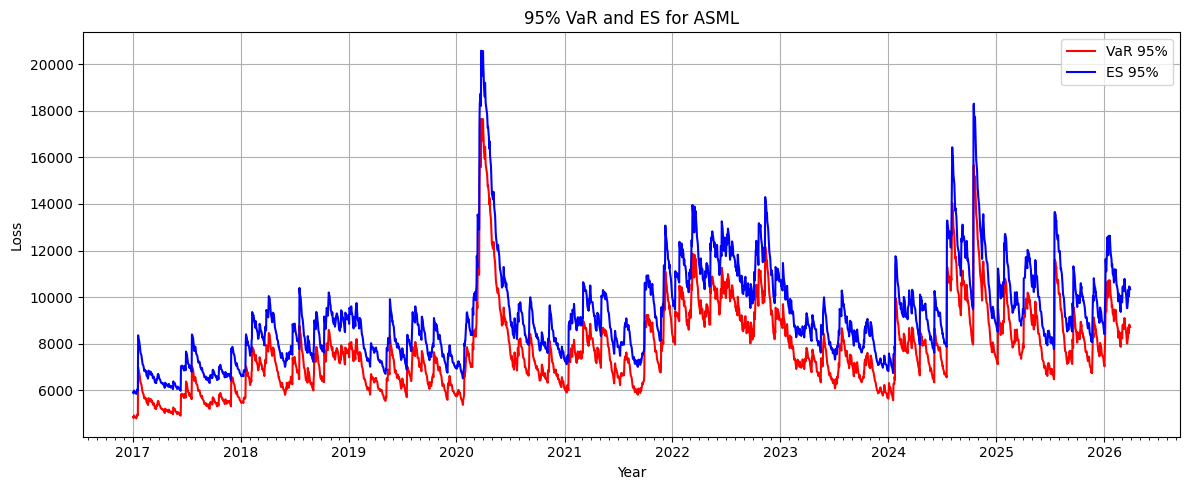

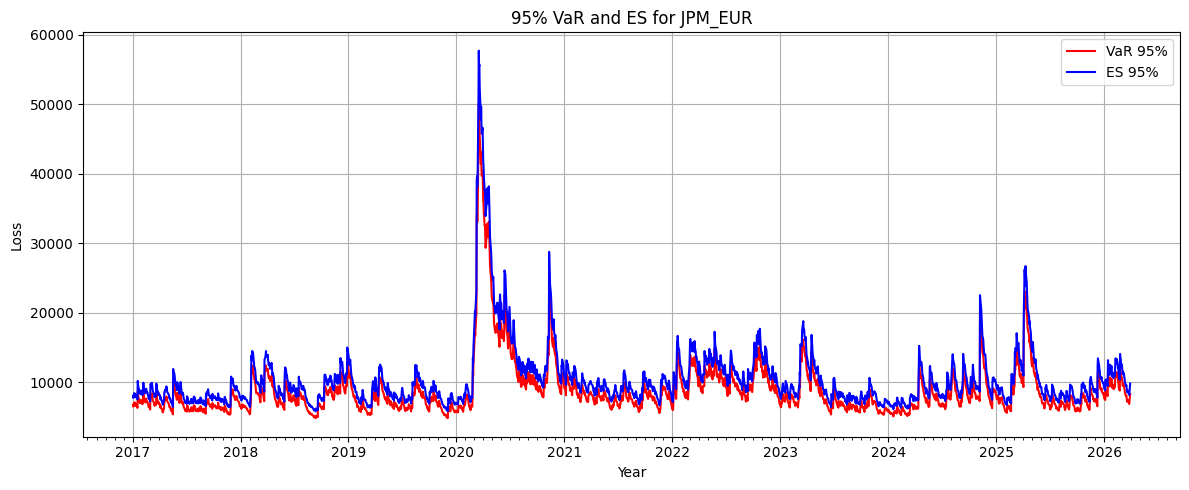

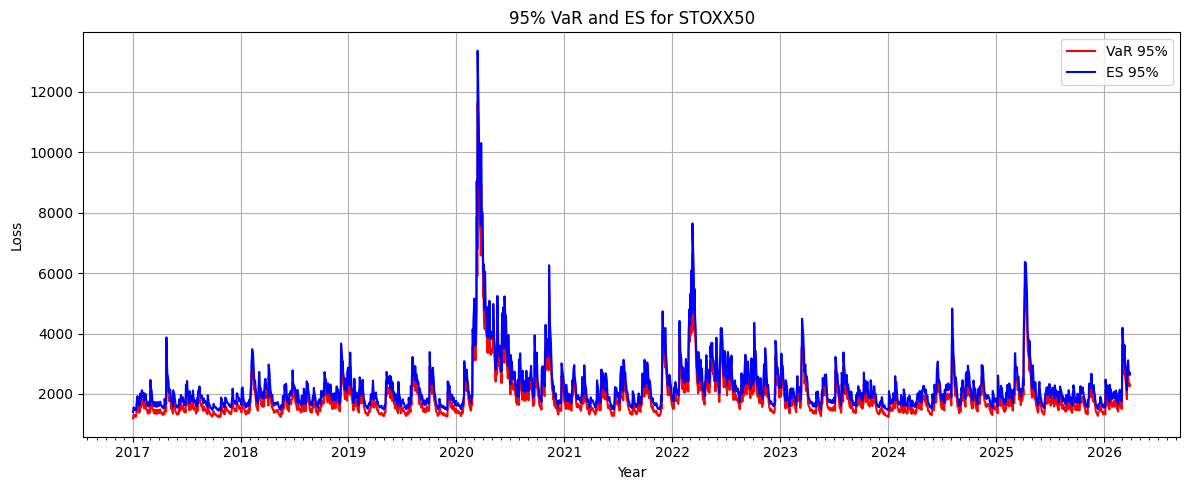

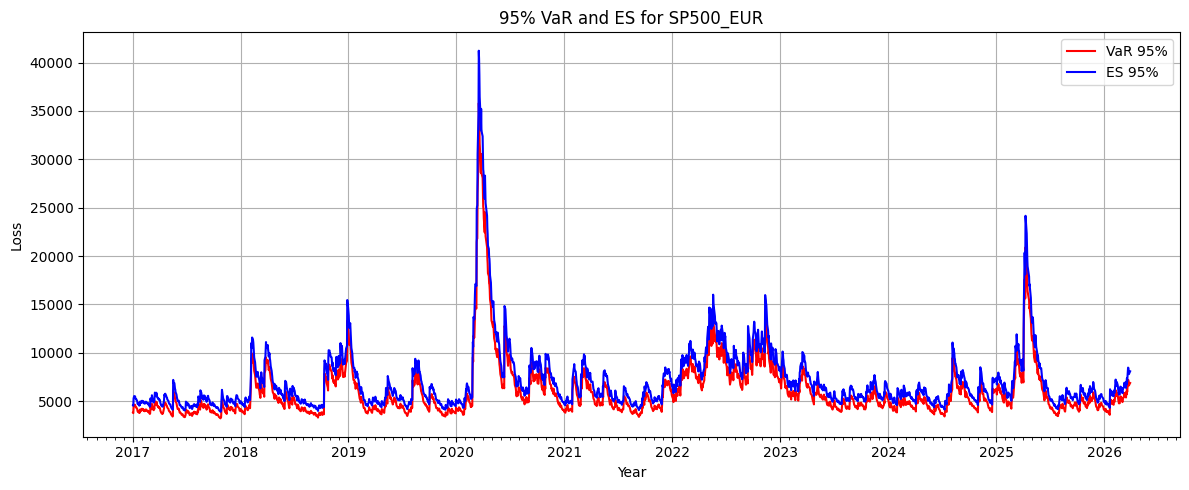

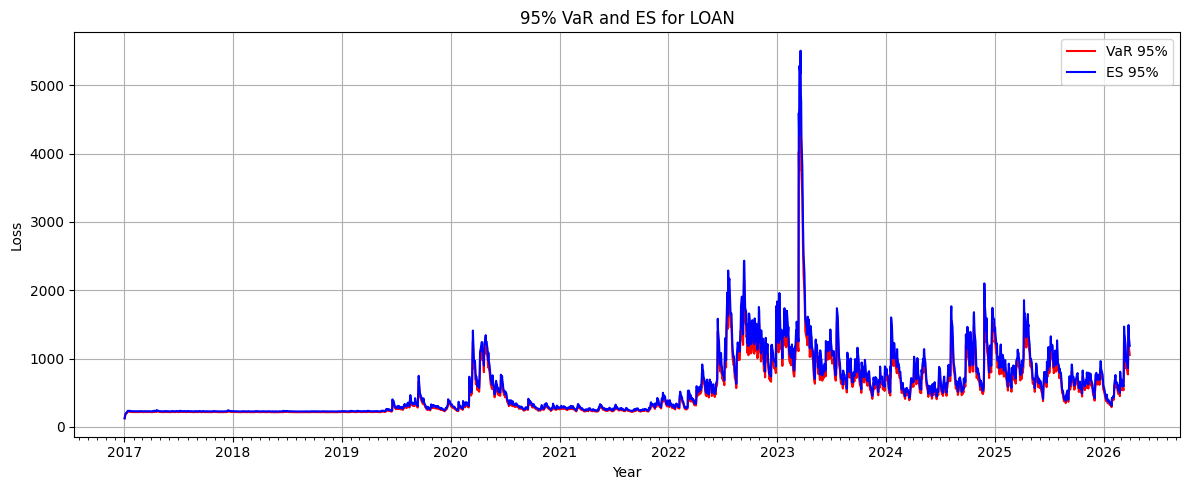

In [130]:
VAR_95.index = pd.to_datetime(VAR_95
.index)
ES_95.index = pd.to_datetime(ES_95
.index)

for asset in assets:
    plt.figure(figsize=(12,5))
    plt.plot(VAR_95
.index, VAR_95
[asset], label='VaR 95%', color='red')
    plt.plot(ES_95
.index, ES_95
[asset], label='ES 95%', color='blue')
    plt.title(f'95% VaR and ES for {asset}')
    plt.xlabel('Year')
    plt.ylabel('Loss')

    ax = plt.gca()


    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


**Conditional  95% 1-day Var and ES for Portfolio**

In [131]:
Portfolio_return = pd.DataFrame(index=risky_returns['Date'],columns=['Port_return'])
for time in Portfolio_return.index:
    Portfolio_return.loc[time,'Port_return'] = 0
    for asset in assets:
        Portfolio_return.loc[time,'Port_return'] += WEIGHTS[asset]* risky_returns.loc[risky_returns['Date'] == time, asset].values[0]

In [132]:
Portfolio_return = PORTFOLIO_VALUE*Portfolio_return[Portfolio_return.index>= SAMPLE_START]

In [133]:
Portfolio_mu = 0
Portfolio_sigma = pd.DataFrame(index=Sigmas_dict.keys(), dtype=float,columns= ['Port_Volatility'])
w = np.array([WEIGHTS[asset] for asset in assets])
for asset in assets:
    Portfolio_mu+= WEIGHTS[asset]*mu[asset]
for date, Sigma_t in Sigmas_dict.items():
    port_var_hat = w.T @ Sigma_t @ w
    Portfolio_sigma.loc[date, 'Port_Volatility'] = np.sqrt(port_var_hat)
Portfolio_sigma = Portfolio_sigma.sort_index()
Portfolio_mu


np.float64(0.00043896985622342137)

In [134]:
Portfolio_VaR_95 = PORTFOLIO_VALUE*(-Portfolio_mu + z * Portfolio_sigma['Port_Volatility'])
Portfolio_ES_95 = PORTFOLIO_VALUE*(Portfolio_mu + Portfolio_sigma['Port_Volatility'] * phi_z / (1 - alpha))


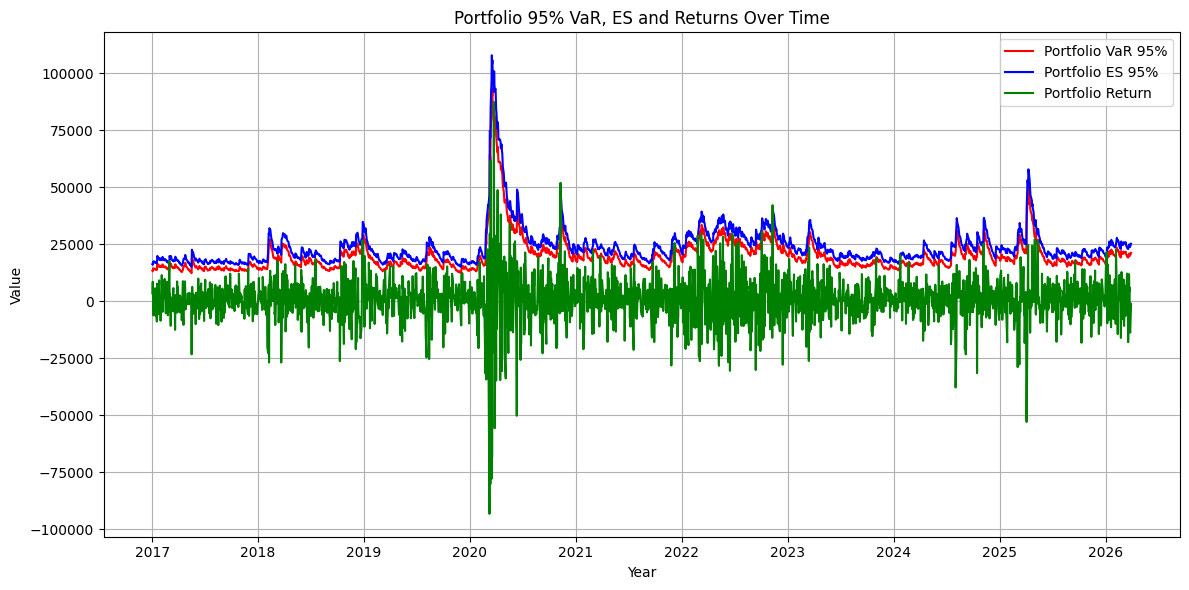

In [135]:
Portfolio_sigma.index = pd.to_datetime(Portfolio_sigma.index)
Portfolio_VaR_95.index = pd.to_datetime(Portfolio_VaR_95.index)
Portfolio_ES_95.index = pd.to_datetime(Portfolio_ES_95.index)

plt.figure(figsize=(12,6))

plt.plot(Portfolio_VaR_95.index, Portfolio_VaR_95.values, label='Portfolio VaR 95%', color='red')
plt.plot(Portfolio_ES_95.index, Portfolio_ES_95.values, label='Portfolio ES 95%', color='blue')
plt.plot(Portfolio_ES_95.index, Portfolio_return.values, label='Portfolio Return', color='green')

plt.title('Portfolio 95% VaR, ES and Returns Over Time')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend()

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.grid(True)
plt.tight_layout()
plt.show()

**Back testing**

In [136]:
Losses= {}
for asset in assets:
    Losses[asset] = in_sample_returns[['Date',asset]]
    Losses[asset][asset] = -ASSET_WEALTH[asset]*in_sample_returns[['Date',asset]][asset]

In [137]:
Losses_Port = -Portfolio_return
Losses_Port.columns = ['Port_loss']
Losses_Port.index = pd.to_datetime(Losses_Port.index)


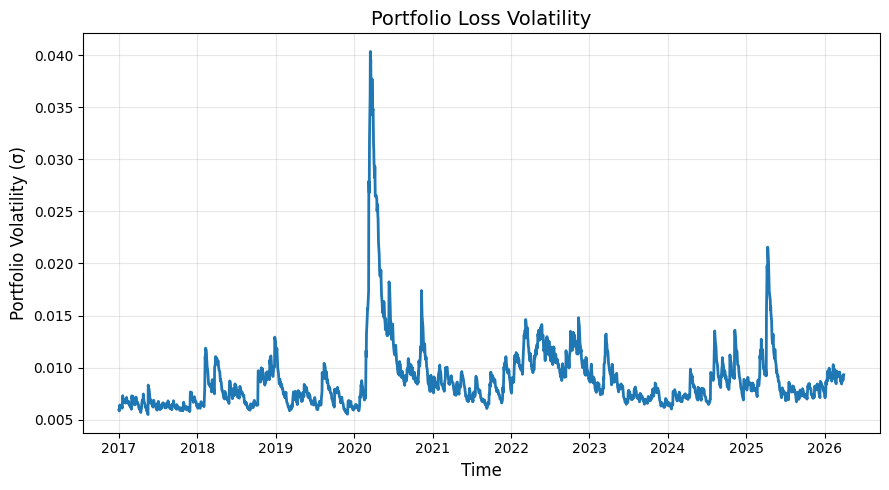

In [138]:

plt.figure(figsize=(9, 5))

plt.plot(
    Portfolio_sigma['Port_Volatility'],
    linewidth=2
)

plt.title("Portfolio Loss Volatility", fontsize=14)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Portfolio Volatility (σ)", fontsize=12)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

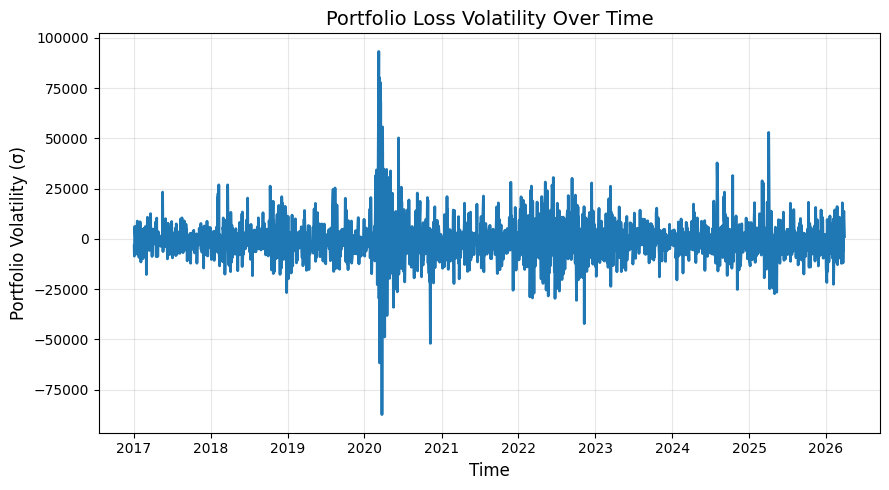

In [139]:

plt.figure(figsize=(9, 5))

plt.plot(
    Losses_Port,
    linewidth=2
)

plt.title("Portfolio Loss Volatility Over Time", fontsize=14)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Portfolio Volatility (σ)", fontsize=12)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

**Portfolio VaR violations and average ES (2025)**

In [140]:


years = list(range(2017, 2027))

alpha_c = 0.05


for i in range(len(years)):

    start = f"{years[i]}-01-01"
    end = f"{years[i] + 1}-01-01" if years[i] < 2026 else "2026-03-30"

    mask = (Losses_Port.index >= start) & (Losses_Port.index <= end)

    loss_series = Losses_Port.loc[mask, 'Port_loss']
    var_series = Portfolio_VaR_95.loc[mask]
    es_series = Portfolio_ES_95.loc[mask]

    loss_series, var_series = loss_series.align(var_series, join='inner')
    loss_series, es_series = loss_series.align(es_series, join='inner')

    violations = loss_series > var_series
    Ic_hat = violations.sum()
    T = len(violations)

    p = 1 - alpha
    expected = T * p

    cL = binom.ppf(alpha_c / 2, T, p)
    cU = binom.ppf(1 - alpha_c / 2, T, p)

    reject_VaR = (Ic_hat < cL) or (Ic_hat > cU)


    if Ic_hat > 0:

        denom = es_series - var_series

        residual = (loss_series - es_series) / denom
        residual = residual[violations]

        residual = residual.replace([np.inf, -np.inf], np.nan).dropna()
        n_t= len(residual)
        K_hat = residual.mean()
        S_k = residual.std()
        df = Ic_hat

        t_lower = t.ppf(alpha_c/2, df)
        t_upper = t.ppf(1 - alpha_c/2, df)

        if len(residual) >= 1:
            t_stat = n_t*K_hat / S_k
            reject_ES = (t_stat < t_lower) or (t_stat > t_upper)
        else:
            t_stat= np.nan
            reject_ES = False

        avg_shortfall = (loss_series[violations]).mean()

    else:
        residual = pd.Series(dtype=float)
        t_stat, p_value = np.nan, np.nan
        reject_ES = False
        avg_shortfall = 0.0

    ES_avg = es_series.mean()


    print(
        f"\nPortfolio ({start} to {end}):\n"
        f"VaR violations = {Ic_hat} / {T} (expected ~{expected:.1f})\n"
        f"VaR critical region: [{cL:.0f}, {cU:.0f}]\n"
        f"Reject VaR H0: {reject_VaR}\n\n"
        f"ES t-test:\n"
        f"t-stat = {t_stat:.4f},CI =  [{t_lower:.4f},{t_upper:.4f}]\n"
        f"Reject ES H0: {reject_ES}\n"
        f"Average shortfall = {avg_shortfall:.4f}\n"
        f"Average ES = {ES_avg:.4f}\n"
    )


Portfolio (2017-01-01 to 2018-01-01):
VaR violations = 1 / 256 (expected ~2.6)
VaR critical region: [0, 6]
Reject VaR H0: False

ES t-test:
t-stat = nan,CI =  [-12.7062,12.7062]
Reject ES H0: False
Average shortfall = 23247.2675
Average ES = 17682.6925


Portfolio (2018-01-01 to 2019-01-01):
VaR violations = 7 / 255 (expected ~2.6)
VaR critical region: [0, 6]
Reject VaR H0: True

ES t-test:
t-stat = 3.3810,CI =  [-2.3646,2.3646]
Reject ES H0: True
Average shortfall = 23432.1043
Average ES = 21914.7618


Portfolio (2019-01-01 to 2020-01-01):
VaR violations = 4 / 255 (expected ~2.6)
VaR critical region: [0, 6]
Reject VaR H0: False

ES t-test:
t-stat = 1.9785,CI =  [-2.7764,2.7764]
Reject ES H0: False
Average shortfall = 21938.3938
Average ES = 20000.1503


Portfolio (2020-01-01 to 2021-01-01):
VaR violations = 10 / 257 (expected ~2.6)
VaR critical region: [0, 6]
Reject VaR H0: True

ES t-test:
t-stat = 4.8787,CI =  [-2.2281,2.2281]
Reject ES H0: True
Average shortfall = 39274.4287
Avera

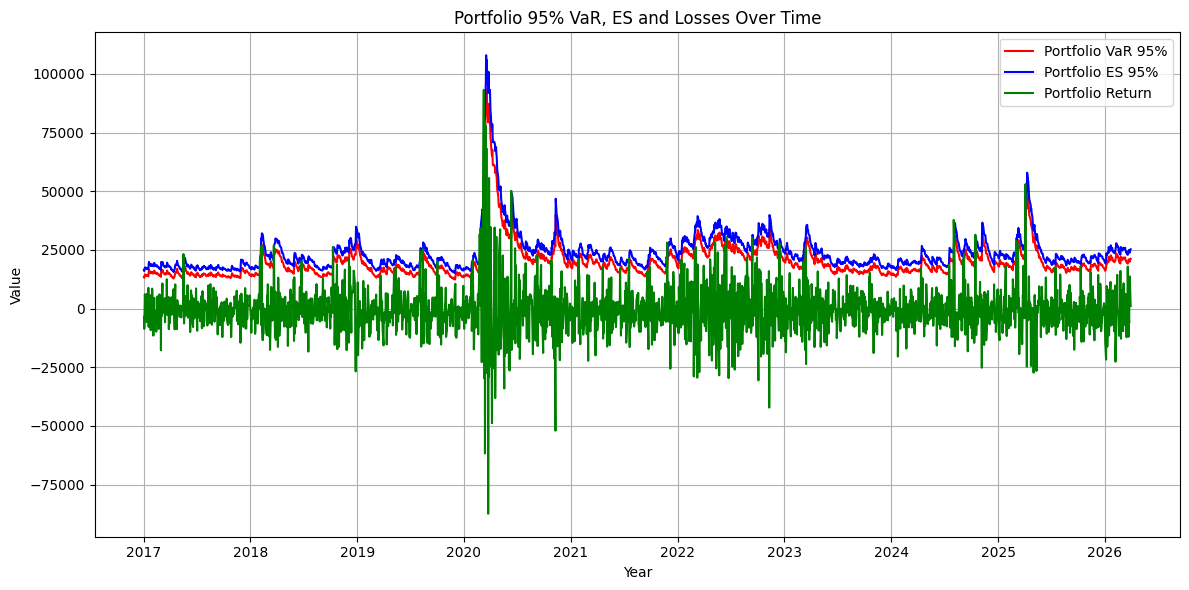

In [141]:
Portfolio_sigma.index = pd.to_datetime(Portfolio_sigma.index)
Portfolio_VaR_95.index = pd.to_datetime(Portfolio_VaR_95.index)
Portfolio_ES_95.index = pd.to_datetime(Portfolio_ES_95.index)

plt.figure(figsize=(12,6))

plt.plot(Portfolio_VaR_95.index, Portfolio_VaR_95.values, label='Portfolio VaR 95%', color='red')
plt.plot(Portfolio_ES_95.index, Portfolio_ES_95.values, label='Portfolio ES 95%', color='blue')
plt.plot(Portfolio_ES_95.index, Losses_Port.values, label='Portfolio Return', color='green')

plt.title('Portfolio 95% VaR, ES and Losses Over Time')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend()

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.grid(True)
plt.tight_layout()
plt.show()

In [142]:
Portfolio_sigma_hat = np.sqrt(w.T @ Sigmas_predicted[0] @ w)

In [143]:
VAR_95_predicted_port = PORTFOLIO_VALUE*(-Portfolio_mu+Portfolio_sigma_hat*z)
ES_95_predicted_port = PORTFOLIO_VALUE*(Portfolio_mu+Portfolio_sigma_hat*phi_z/(1-alpha) )

In [144]:
VAR_95_predicted['Portfolio'] = VAR_95_predicted_port
ES_95_predicted['Portfolio'] = ES_95_predicted_port
ES_95_predicted

{'SHELL': np.float64(3396.5796322849956),
 'ASML': np.float64(10500.221558285326),
 'JPM_EUR': np.float64(9452.460739867045),
 'STOXX50': np.float64(2446.3049944522227),
 'SP500_EUR': np.float64(7670.152725500009),
 'LOAN': np.float64(1059.8754942405653),
 'Portfolio': np.float64(24667.531298979837)}

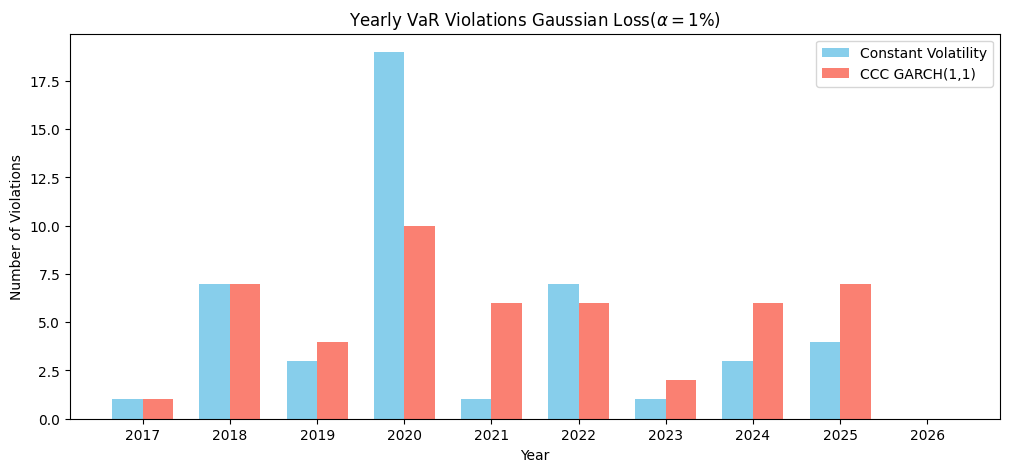

In [145]:


years = np.array([2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026])
violations_const = np.array([1, 7, 3, 19, 1, 7, 1, 3, 4, 0])  # constant volatility
violations_garch = np.array([1, 7, 4, 10, 6, 6, 2, 6, 7, 0])  # CCC-GARCH(1,1)
width = 0.35
plt.figure(figsize=(12,5))
plt.bar(years - width/2, violations_const, width=width, color='skyblue', label='Constant Volatility')
plt.bar(years + width/2, violations_garch, width=width, color='salmon', label='CCC GARCH(1,1)')
plt.title("Yearly VaR Violations Gaussian Loss($\\alpha = 1\\%$)")
plt.xlabel("Year")
plt.ylabel("Number of Violations")
plt.xticks(years)
plt.legend()
plt.show()

## **Tasks 5: Methods 3 (Historical) & 5 (EWMA Hisorical)**

In [146]:
DATA_RETURNS = 'data/returns_clean.csv'
DATA_PRICES  = 'data/prices_clean.csv'

STOCKS   = ['ASML', 'SHELL', 'JPM']
INDEX    = ['STOXX50', 'SP500']
RISKY    = STOCKS + INDEX

SAMPLE_START = '2017-01-01'
SAMPLE_END   = '2026-03-31'

PORTFOLIO_VALUE = 1_000_000
TRADING_DAYS    = 252
LOAN_MOD_DUR    = 9.135099

#Old weights here 
# WEIGHTS = {
#     'ASML':    0.178207,
#     'SHELL':   0.040000,
#     'JPM':     0.320000,
#     'STOXX50': 0.040000,
#     'SP500':   0.221793,
#     'LOAN':    0.200000,
# }

WEIGHTS = {
    "ASML": 0.160000,
    "SHELL": 0.080000,
    "JPM_EUR": 0.240000,
    "STOXX50": 0.080000,
    "SP500_EUR": 0.240000,
    "LOAN": 0.200000,
}

ASSETS = list(WEIGHTS.keys())
w      = np.array([WEIGHTS[c] for c in ASSETS])
ALPHAS = [0.99, 0.975]

**Methods 3 (Historical Simulation)**

In [147]:
returns = pd.read_csv(DATA_RETURNS, index_col=0, parse_dates=True)
ret     = returns.loc[SAMPLE_START:SAMPLE_END, ASSETS].dropna()
n       = len(ret)
# portfolio loss
loss     = -PORTFOLIO_VALUE * (ret.values @ w)
# per asset losses
loss_mat = -PORTFOLIO_VALUE * (ret.values * w)

In [148]:
results_ind  = {}
results_port = {}

for alpha in ALPHAS:
    K    = int(np.ceil(n * alpha))
    frac = K - n * alpha

    ls    = np.sort(loss)
    var_p = ls[K - 1]
    es_p  = (ls[K:].sum() + frac * var_p) / (n * (1 - alpha))
    results_port[alpha] = {'VaR': var_p, 'ES': es_p}

    results_ind[alpha] = {}
    for i, col in enumerate(ASSETS):
        ls_i  = np.sort(loss_mat[:, i])
        var_i = ls_i[K - 1]
        es_i  = (ls_i[K:].sum() + frac * var_i) / (n * (1 - alpha))
        results_ind[alpha][col] = {'VaR': var_i, 'ES': es_i}

In [149]:
print(f"{'Asset':<12}  {'VaR 99%':>10}  {'ES 99%':>10}  {'VaR 97.5%':>10}  {'ES 97.5%':>10}")
print('-' * 58)
for col in ASSETS:
    v99, e99   = results_ind[0.99][col]['VaR'],   results_ind[0.99][col]['ES']
    v975, e975 = results_ind[0.975][col]['VaR'],  results_ind[0.975][col]['ES']
    print(f"{col:<12}  {v99:>10,.0f}  {e99:>10,.0f}  {v975:>10,.0f}  {e975:>10,.0f}")
print('-' * 58)
v99, e99   = results_port[0.99]['VaR'],   results_port[0.99]['ES']
v975, e975 = results_port[0.975]['VaR'],  results_port[0.975]['ES']
print(f"{'PORTFOLIO':<12}  {v99:>10,.0f}  {e99:>10,.0f}  {v975:>10,.0f}  {e975:>10,.0f}")

Asset            VaR 99%      ES 99%   VaR 97.5%    ES 97.5%
----------------------------------------------------------
ASML               9,489      13,115       7,142      10,013
SHELL              4,168       6,394       2,867       4,613
JPM_EUR           11,674      17,657       8,301      12,998
STOXX50            2,929       3,922       1,809       2,943
SP500_EUR          8,107      12,455       6,170       9,205
LOAN                 941       1,263         648         973
----------------------------------------------------------
PORTFOLIO         27,799      43,440      20,134      31,305


**Methods 5 (Filtered Historical Simulation)**

In [150]:
lam   = 0.94
r_arr = ret[ASSETS].values
sigma   = np.zeros((n, len(ASSETS)))

for i in range(len(ASSETS)):
    sigma[0, i] = np.var(r_arr[:, i])
    for t in range(1, n):
        sigma[t, i] = lam * sigma[t-1, i] + (1 - lam) * r_arr[t-1, i] ** 2

sigma = np.sqrt(sigma)

In [151]:
z = r_arr / sigma
sigma_next = np.sqrt(lam * sigma[-1] ** 2 + (1 - lam) * r_arr[-1] ** 2)
r_sim    = z * sigma_next

In [152]:
loss_sim     = -PORTFOLIO_VALUE * (r_sim @ w)
loss_sim_ind = -PORTFOLIO_VALUE * (r_sim * w)

In [153]:
f_results_ind  = {}
f_results_port = {}

for alpha in ALPHAS:
    K    = int(np.ceil(n * alpha))
    frac = K - n * alpha

    ls    = np.sort(loss_sim)
    var_p = ls[K - 1]
    es_p  = (ls[K:].sum() + frac * var_p) / (n * (1 - alpha))
    f_results_port[alpha] = {'VaR': var_p, 'ES': es_p}

    f_results_ind[alpha] = {}
    for i, col in enumerate(ASSETS):
        ls_i  = np.sort(loss_sim_ind[:, i])
        var_i = ls_i[K - 1]
        es_i  = (ls_i[K:].sum() + frac * var_i) / (n * (1 - alpha))
        f_results_ind[alpha][col] = {'VaR': var_i, 'ES': es_i}

In [154]:
print(f"{'Asset':<12}  {'VaR 99%':>10}  {'ES 99%':>10}  {'VaR 97.5%':>10}  {'ES 97.5%':>10}")
print('-' * 58)
for col in ASSETS:
    v99, e99   = f_results_ind[0.99][col]['VaR'],   f_results_ind[0.99][col]['ES']
    v975, e975 = f_results_ind[0.975][col]['VaR'],  f_results_ind[0.975][col]['ES']
    print(f"{col:<12}  {v99:>10,.0f}  {e99:>10,.0f}  {v975:>10,.0f}  {e975:>10,.0f}")
print('-' * 58)
v99, e99   = f_results_port[0.99]['VaR'],   f_results_port[0.99]['ES']
v975, e975 = f_results_port[0.975]['VaR'],  f_results_port[0.975]['ES']
print(f"{'PORTFOLIO':<12}  {v99:>10,.0f}  {e99:>10,.0f}  {v975:>10,.0f}  {e975:>10,.0f}")

Asset            VaR 99%      ES 99%   VaR 97.5%    ES 97.5%
----------------------------------------------------------
ASML              11,753      16,334       8,495      12,543
SHELL              4,008       5,306       2,947       4,165
JPM_EUR           10,595      13,609       7,838      10,839
STOXX50            3,140       4,181       2,429       3,306
SP500_EUR          8,231      10,734       6,048       8,465
LOAN                 975       1,362         733       1,031
----------------------------------------------------------
PORTFOLIO         28,053      35,499      20,981      28,536


**Backtesting**

In [155]:
alpha_bt = 0.99
min_obs = 250

results_var  = {a: np.full(n, np.nan) for a in ALPHAS}
results_es   = {a: np.full(n, np.nan) for a in ALPHAS}
fresults_var = {a: np.full(n, np.nan) for a in ALPHAS}
fresults_es  = {a: np.full(n, np.nan) for a in ALPHAS}

for t in range(min_obs - 1, n - 1):
    sig_t   = sigma[t + 1]
    r_sim_t = z[:t + 1] * sig_t
    ls_fhs  = np.sort(-PORTFOLIO_VALUE * (r_sim_t @ w))
    ls_hs   = np.sort(loss[:t + 1])
    m       = t + 1

    for a in ALPHAS:
        K    = int(np.ceil(m * a))
        frac = K - m * a

        results_var[a][t + 1]  = ls_hs[K - 1]
        results_es[a][t + 1]   = (ls_hs[K:].sum()  + frac * ls_hs[K - 1])  / (m * (1 - a))
        fresults_var[a][t + 1] = ls_fhs[K - 1]
        fresults_es[a][t + 1]  = (ls_fhs[K:].sum() + frac * ls_fhs[K - 1]) / (m * (1 - a))

bt      = np.arange(min_obs, n)
bt_loss = loss[bt]
bt_dates = ret.index[bt]
m_bt    = len(bt)

**VaR violations + binomial test**

In [156]:
print(f"{'Method':<12}  {'Alpha':>6}  {'Expected':>9}  {'Actual':>9}  {'Z':>8}  {'p':>7}")
print("-" * 62)
for label, vd in [("HS", results_var), ("FHS-EWMA", fresults_var)]:
    for a in ALPHAS:
        I    = (bt_loss > vd[a][bt]).astype(int)
        M    = I.sum()
        exp  = m_bt * (1 - a)
        Z    = (M - exp) / np.sqrt(m_bt * a * (1 - a))
        p    = 2 * (1 - stats.norm.cdf(abs(Z)))
        print(f"{label:<12}  {a*100:>5.1f}%  {exp:>9.1f}  {M:>9d}  {Z:>8.3f}  {p:>7.4f}")

Method         Alpha   Expected     Actual         Z        p
--------------------------------------------------------------
HS             99.0%       21.2         27     1.276   0.2020
HS             97.5%       52.9         67     1.963   0.0496
FHS-EWMA       99.0%       21.2         19    -0.472   0.6370
FHS-EWMA       97.5%       52.9         54     0.153   0.8783


**ES violation residuals t-test**

In [157]:
print(f"{'Method':<12}  {'Alpha':>6}  {'N viol':>7}  {'Mean K':>9}  {'t':>8}  {'p':>7}")
print("-" * 58)
for label, vd, ed in [("HS", results_var, results_es), ("FHS-EWMA", fresults_var, fresults_es)]:
    for a in ALPHAS:
        I  = bt_loss > vd[a][bt]
        K  = np.where(I, (bt_loss - ed[a][bt]) / ed[a][bt], 0.0)
        Kv = K[I]
        t_s, p = stats.ttest_1samp(Kv, 0)
        print(f"{label:<12}  {a*100:>5.1f}%  {len(Kv):>7}  {Kv.mean():>9.4f}  {t_s:>8.3f}  {p:>7.4f}")

Method         Alpha   N viol     Mean K         t        p
----------------------------------------------------------
HS             99.0%       27     0.1527     1.493   0.1475
HS             97.5%       67     0.0721     1.044   0.3002
FHS-EWMA       99.0%       19     0.0055     0.117   0.9079
FHS-EWMA       97.5%       54    -0.0258    -0.705   0.4839


**Elicitability VaR score**

In [158]:
print(f"{'Method':<12}  {'Alpha':>6}  {'Score':>14}")
print("-" * 36)
for label, vd in [("HS", results_var), ("FHS-EWMA", fresults_var)]:
    for a in ALPHAS:
        vt    = vd[a][bt]
        score = np.sum(np.abs((bt_loss <= vt).astype(float) - a) * np.abs(bt_loss - vt))
        print(f"{label:<12}  {a*100:>5.1f}%  {score:>14,.0f}")

Method         Alpha           Score
------------------------------------
HS             99.0%       1,014,087
HS             97.5%       1,809,545
FHS-EWMA       99.0%         783,103
FHS-EWMA       97.5%       1,537,944


**Violations plot**

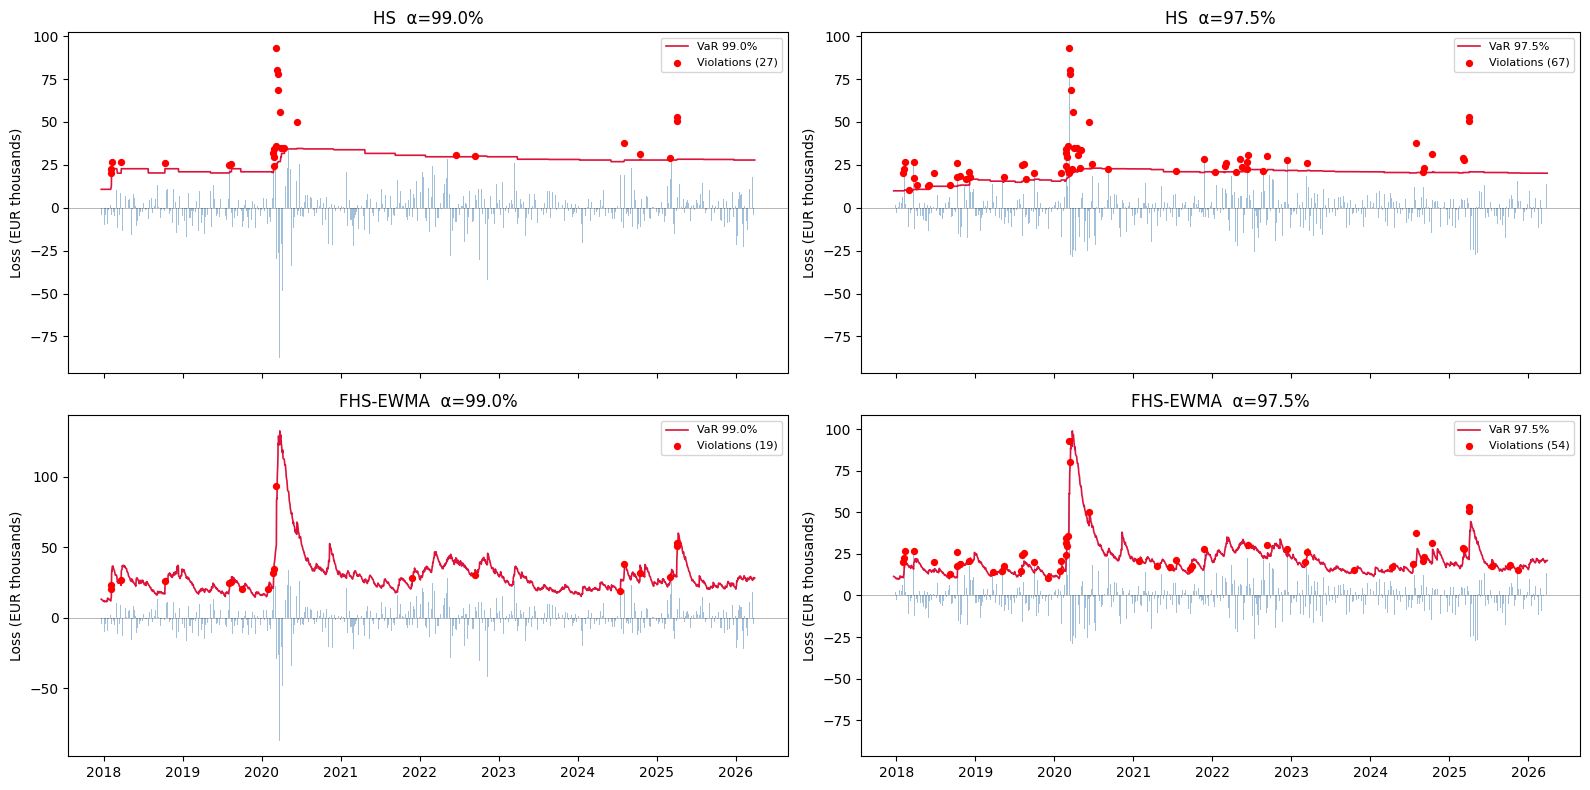

In [159]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=True)
for row, (label, vd) in enumerate([("HS", results_var), ("FHS-EWMA", fresults_var)]):
    for col, a in enumerate(ALPHAS):
        ax = axes[row, col]
        vt = vd[a][bt]
        I  = bt_loss > vt
        ax.bar(bt_dates, bt_loss / 1e3, color="steelblue", alpha=0.5, width=1)
        ax.plot(bt_dates, vt / 1e3, color="crimson", lw=1.2, label=f"VaR {a*100:.1f}%")
        ax.scatter(bt_dates[I], bt_loss[I] / 1e3, color="red", s=18, zorder=5,
                   label=f"Violations ({I.sum()})")
        ax.axhline(0, color="black", lw=0.5, alpha=0.4)
        ax.set_title(f"{label}  α={a*100:.1f}%")
        ax.set_ylabel("Loss (EUR thousands)")
        ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("plots/backtest_violations.png", dpi=150)
plt.show()

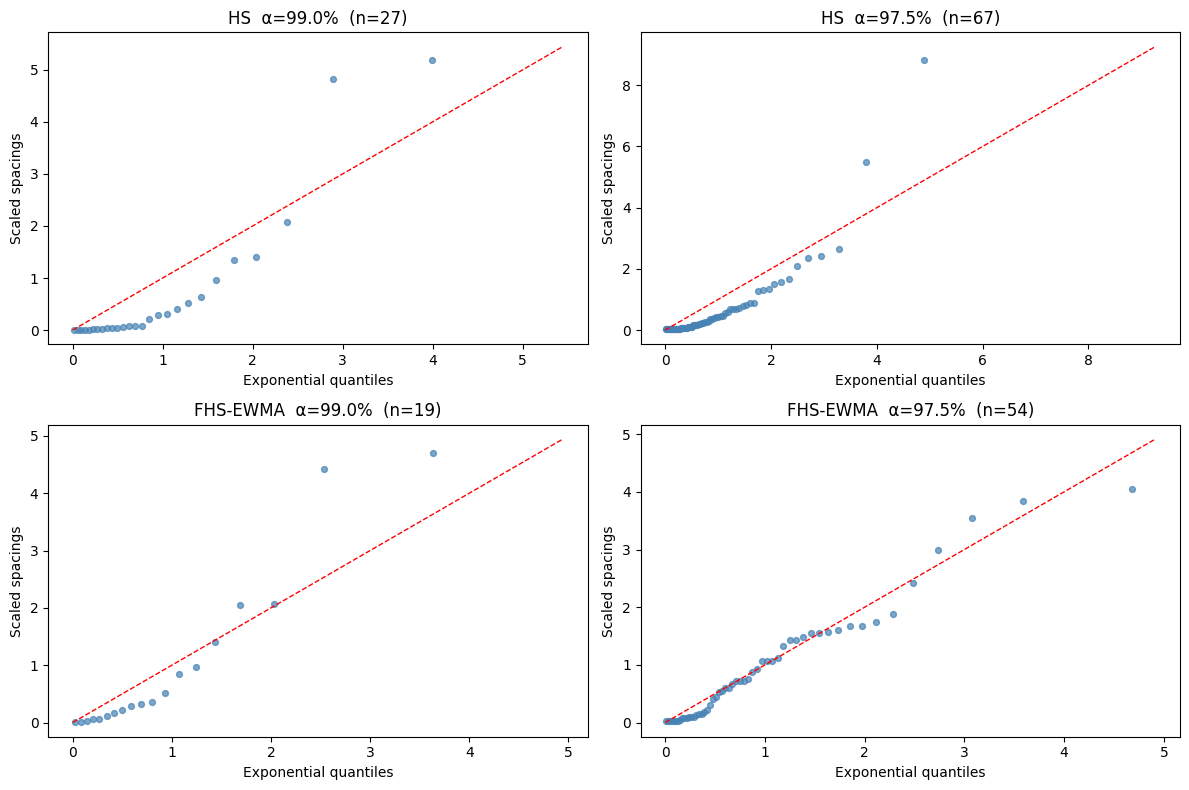

In [160]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for row, (label, vd) in enumerate([("HS", results_var), ("FHS-EWMA", fresults_var)]):
    for col, a in enumerate(ALPHAS):
        ax      = axes[row, col]
        I       = bt_loss > vd[a][bt]
        vdays   = np.where(I)[0]
        spacing = np.diff(np.concatenate([[0], vdays])) * (1 - a)
        s_sort  = np.sort(spacing)
        probs   = (np.arange(1, len(s_sort) + 1) - 0.5) / len(s_sort)
        exp_q   = -np.log(1 - probs)
        ax.scatter(exp_q, s_sort, s=18, alpha=0.7, color="steelblue")
        lim = max(exp_q.max(), s_sort.max()) * 1.05
        ax.plot([0, lim], [0, lim], "r--", lw=1)
        ax.set_xlabel("Exponential quantiles")
        ax.set_ylabel("Scaled spacings")
        ax.set_title(f"{label}  α={a*100:.1f}%  (n={len(spacing)})")
plt.tight_layout()
plt.savefig("plots/backtest_qqplot.png", dpi=150)
plt.show()

## **Task 6: 1-, 5-, 10-day VaR & square-root-of-time scaling**

In [161]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_RETURNS = "data/returns_clean.csv"
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

# ── Sample period ─────────────────────────────────────────────────────────────
SAMPLE_START = "2017-01-01"
SAMPLE_END   = "2026-03-31"

# ── Portfolio setup ────────────────────────────
PORTFOLIO_VALUE = 1_000_000
TRADING_DAYS    = 252
ALPHAS          = [0.99, 0.975]   # confidence levels

WEIGHTS = {
    "ASML":      0.16,
    "SHELL":     0.08,
    "JPM_EUR":   0.24,
    "STOXX50":   0.08,
    "SP500_EUR": 0.24,
    "LOAN":      0.20,
}

ASSETS = list(WEIGHTS.keys())
w = np.array([WEIGHTS[a] for a in ASSETS])

assert abs(w.sum() - 1.0) < 1e-10, "Portfolio weights must sum to 1."


In [162]:
# Load returns and convert to simple returns

raw_returns = pd.read_csv(DATA_RETURNS, index_col=0, parse_dates=True).sort_index()
raw_returns = raw_returns.loc[SAMPLE_START:SAMPLE_END]

# Convert log-returns to simple returns for risky assets.
# The loan series in Notebook 01 is already constructed as an approximate simple return.
simple_returns = pd.DataFrame(index=raw_returns.index)

for col in ASSETS:
    if col == "LOAN":
        simple_returns[col] = raw_returns[col]
    else:
        simple_returns[col] = np.expm1(raw_returns[col])

simple_returns = simple_returns.dropna()

print(f"Sample range: {simple_returns.index.min().date()} → {simple_returns.index.max().date()}")
print(f"Number of daily observations: {len(simple_returns)}")
display(simple_returns.head())


Sample range: 2017-01-02 → 2026-03-30
Number of daily observations: 2366


,ASML,SHELL,JPM_EUR,STOXX50,SP500_EUR,LOAN
Date,,,,,,
2017-01-02,0.003751,0.009044,0.004590,0.000000,0.004590,-0.000044
2017-01-03,-0.004204,0.012014,0.017364,0.007446,0.014941,0.000138
2017-01-04,-0.013602,0.004899,0.005701,0.000754,0.009594,0.000138
2017-01-05,0.002377,-0.005063,-0.016845,-0.000317,-0.008475,0.000138
2017-01-06,0.000000,-0.003958,-0.009787,0.001417,-0.006420,0.000047


In [163]:
# Helper functions
def historical_var_es(losses, alpha):
    """
    Historical VaR/ES for a vector of losses and confidence level alpha.
    alpha is a confidence level, e.g. 0.99 or 0.975.
    """
    losses = np.asarray(losses, dtype=float)
    losses = np.sort(losses)
    n = len(losses)

    K = int(np.ceil(n * alpha))
    frac = K - n * alpha

    var = losses[K - 1]
    es  = (losses[K:].sum() + frac * var) / (n * (1 - alpha))

    return var, es

def make_non_overlapping_returns(r, horizon):
    """
    Construct non-overlapping horizon-day simple returns from daily simple returns.
    Uses consecutive blocks starting from the beginning of the sample and drops
    the final incomplete block.
    """
    r = pd.Series(r).dropna()
    n_full = len(r) // horizon
    trimmed = r.iloc[:n_full * horizon].to_numpy().reshape(n_full, horizon)

    # Compound within each block
    block_returns = np.prod(1 + trimmed, axis=1) - 1

    # Use block end date as time stamp
    block_dates = r.index[horizon - 1 : n_full * horizon : horizon]

    return pd.Series(block_returns, index=block_dates, name=f"{horizon}d_return")

In [164]:
# Compute 1-, 5-, and 10-day historical VaR with square-root-of-time comparison
port_ret_1d = pd.Series(simple_returns[ASSETS].values @ w, index=simple_returns[ASSETS].index, name="portfolio_return")

horizons = [1, 5, 10]
results = []

for h in horizons:
    r_h = make_non_overlapping_returns(port_ret_1d, h)
    losses_h = -PORTFOLIO_VALUE * r_h

    for alpha in ALPHAS:
        var_h, es_h = historical_var_es(losses_h, alpha)

        # Square-root-of-time scaling from 1-day VaR
        var_1d, _ = historical_var_es(-PORTFOLIO_VALUE * port_ret_1d, alpha)
        var_srot = var_1d * np.sqrt(h)

        results.append({
            "horizon_days": h,
            "alpha": alpha,
            "n_nonoverlap_obs": len(r_h),
            "HS_VaR_eur": var_h,
            "HS_ES_eur": es_h,
            "SROT_VaR_eur": var_srot,
            "difference_eur": var_srot - var_h,
            "difference_pct_of_HS": 100 * (var_srot / var_h - 1),
        })

results_df = pd.DataFrame(results)
print(results_df.round(2))

   horizon_days  alpha  n_nonoverlap_obs  HS_VaR_eur  HS_ES_eur  SROT_VaR_eur  \
0             1   0.99              2366    27242.59   41791.62      27242.59   
1             1   0.98              2366    19724.32   30393.76      19724.32   
2             5   0.99               473    56591.34   73047.05      60916.28   
3             5   0.98               473    41046.97   58962.46      44104.93   
4            10   0.99               236    90926.42  129224.11      86148.62   
5            10   0.98               236    70123.72   99839.63      62373.79   

   difference_eur  difference_pct_of_HS  
0            0.00                  0.00  
1            0.00                  0.00  
2         4324.94                  7.64  
3         3057.96                  7.45  
4        -4777.80                 -5.25  
5        -7749.93                -11.05  


In [165]:
# Summary table
summary_table = (
    results_df
    .copy()
    .assign(
        alpha=lambda x: (x["alpha"] * 100).map(lambda v: f"{v:.1f}%")
    )
    [["horizon_days", "alpha", "n_nonoverlap_obs", "HS_VaR_eur", "HS_ES_eur",
      "SROT_VaR_eur", "difference_eur", "difference_pct_of_HS"]]
)

print("Historical Simulation vs Square-Root-of-Time")
print(summary_table.round(0))

Historical Simulation vs Square-Root-of-Time
   horizon_days  alpha  n_nonoverlap_obs  HS_VaR_eur  HS_ES_eur  SROT_VaR_eur  \
0             1  99.0%              2366     27243.0    41792.0       27243.0   
1             1  97.5%              2366     19724.0    30394.0       19724.0   
2             5  99.0%               473     56591.0    73047.0       60916.0   
3             5  97.5%               473     41047.0    58962.0       44105.0   
4            10  99.0%               236     90926.0   129224.0       86149.0   
5            10  97.5%               236     70124.0    99840.0       62374.0   

   difference_eur  difference_pct_of_HS  
0             0.0                   0.0  
1             0.0                   0.0  
2          4325.0                   8.0  
3          3058.0                   7.0  
4         -4778.0                  -5.0  
5         -7750.0                 -11.0  


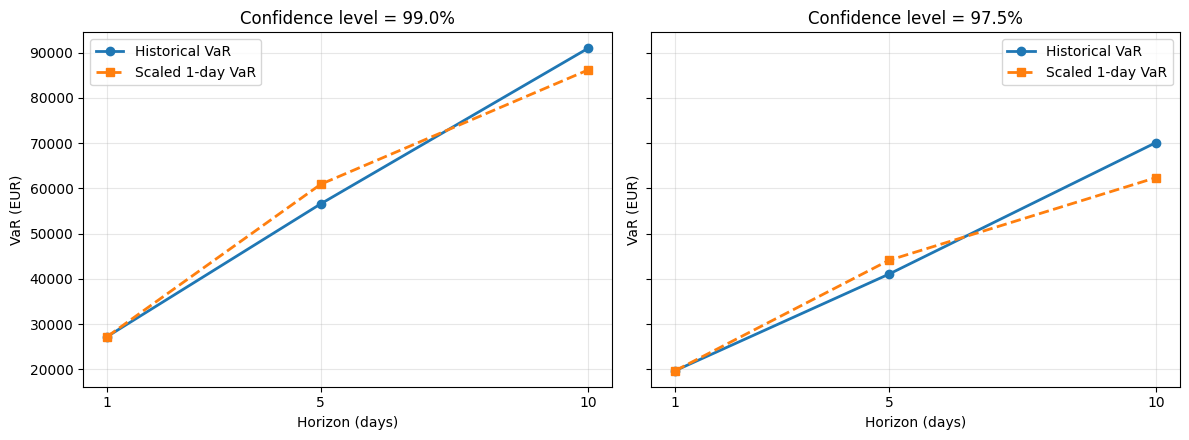

In [166]:
# Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, alpha in zip(axes, ALPHAS):
    sub = results_df[results_df["alpha"] == alpha].sort_values("horizon_days")

    ax.plot(sub["horizon_days"], sub["HS_VaR_eur"], marker="o", linewidth=2, label="Historical VaR")
    ax.plot(sub["horizon_days"], sub["SROT_VaR_eur"], marker="s", linewidth=2, linestyle="--",
            label="Scaled 1-day VaR")

    ax.set_title(f"Confidence level = {alpha*100:.1f}%")
    ax.set_xlabel("Horizon (days)")
    ax.set_ylabel("VaR (EUR)")
    ax.set_xticks([1, 5, 10])
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / "05_multiday_var_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

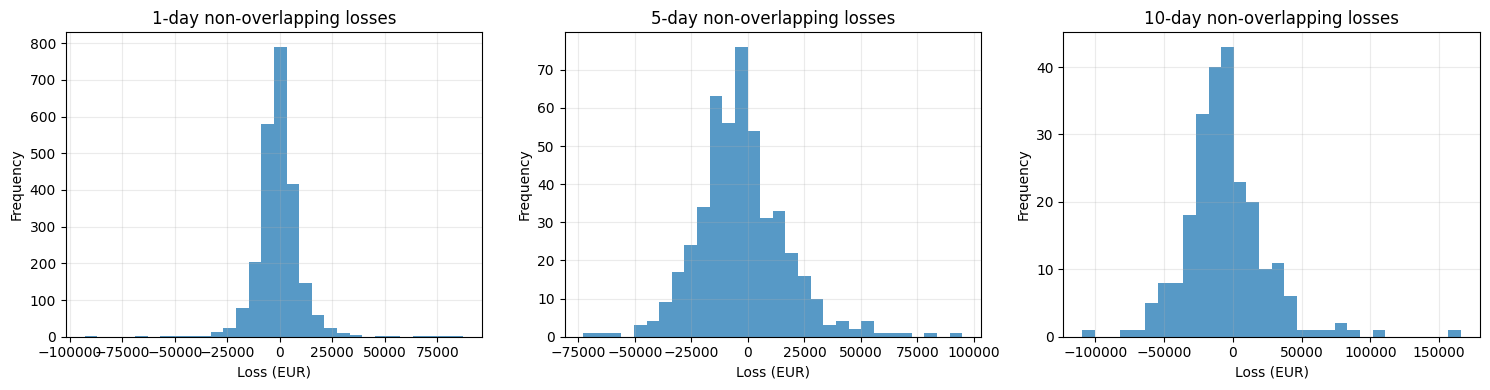

In [167]:
# Loss distributions by horizon
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, h in zip(axes, horizons):
    r_h = make_non_overlapping_returns(port_ret_1d, h)
    losses_h = -PORTFOLIO_VALUE * r_h

    ax.hist(losses_h, bins=30, alpha=0.75)
    ax.set_title(f"{h}-day non-overlapping losses")
    ax.set_xlabel("Loss (EUR)")
    ax.set_ylabel("Frequency")
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "05_multiday_loss_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## **Task 7: Stress testing & shock scenarios**

In [168]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_RETURNS = "data/returns_clean.csv"
DATA_PRICES  = "data/prices_clean.csv"
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

# ── Sample period ─────────────────────────────────────────────────────────────
SAMPLE_START = "2017-01-01"
SAMPLE_END   = "2026-03-31"

# ── Portfolio setup ────────────────────────────
PORTFOLIO_VALUE = 1_000_000
ALPHA_STRESS    = 0.99
TRADING_DAYS    = 252
LOAN_MOD_DUR    = 9.135099  

WEIGHTS = {
    "ASML":      0.16,
    "SHELL":     0.08,
    "JPM_EUR":   0.24,
    "STOXX50":   0.08,
    "SP500_EUR": 0.24,
    "LOAN":      0.20,
}

ASSETS = list(WEIGHTS.keys())
w = np.array([WEIGHTS[a] for a in ASSETS])

assert abs(w.sum() - 1.0) < 1e-10


In [169]:
# Load data
prices = pd.read_csv(DATA_PRICES, index_col=0, parse_dates=True).sort_index()
prices = prices.loc[:SAMPLE_END]

raw_returns = pd.read_csv(DATA_RETURNS, index_col=0, parse_dates=True).sort_index()
raw_returns = raw_returns.loc[SAMPLE_START:SAMPLE_END]

# Convert to simple returns for portfolio risk calculations
simple_returns = pd.DataFrame(index=raw_returns.index)
for col in ASSETS:
    if col == "LOAN":
        simple_returns[col] = raw_returns[col]
    else:
        simple_returns[col] = np.expm1(raw_returns[col])

simple_returns = simple_returns.dropna()

current_date = prices.index.max()
current_prices = prices.loc[current_date].copy()

print(f"Current stress-test date: {current_date.date()}")
print(current_prices.to_frame("current_value"))

Current stress-test date: 2026-03-30
           current_value
ASML         1112.000000
SHELL          40.915001
JPM           282.325134
STOXX50      5541.790039
SP500        6343.720215
EURUSD          1.149201
EURIBOR3M       2.122000
JPM_EUR       245.670873
SP500_EUR    5520.115274


In [170]:
# Base portfolio value and base 1-day historical VaR
def historical_var_es(losses, alpha):
    losses = np.asarray(losses, dtype=float)
    losses = np.sort(losses)
    n = len(losses)

    K = int(np.ceil(n * alpha))
    frac = K - n * alpha

    var = losses[K - 1]
    es  = (losses[K:].sum() + frac * var) / (n * (1 - alpha))
    return var, es

base_port_ret = pd.Series(simple_returns[ASSETS].values @ w, index=simple_returns.index)
base_losses = -PORTFOLIO_VALUE * base_port_ret

base_var, base_es = historical_var_es(base_losses, ALPHA_STRESS)

print(f"Base 1-day historical VaR ({ALPHA_STRESS*100:.1f}%): €{base_var:,.0f}")
print(f"Base 1-day historical ES  ({ALPHA_STRESS*100:.1f}%): €{base_es:,.0f}")

Base 1-day historical VaR (99.0%): €27,243
Base 1-day historical ES  (99.0%): €41,792


In [171]:
# Stress testing functions

def equity_stress_multiplier(shock):
    """
    Shock is expressed as a relative move in price, e.g. +0.20 or -0.40.
    """
    return 1 + shock


def fx_stress_multiplier_eur_value(shock):
    """
    EURUSD is quoted as USD per EUR.
    
    If EURUSD rises, one euro buys more dollars, so USD assets are worth less in EUR.
    EUR value multiplier for USD assets = 1 / (1 + shock).
    """
    return 1 / (1 + shock)


def rate_stress_multiplier_loan(shock_abs):
    """
    Approximate loan value change from a parallel rate shift using modified duration:
        dP/P ≈ -D_mod * dy
    where shock_abs is in decimal, e.g. +0.02 for +2%.
    """
    return 1 - LOAN_MOD_DUR * shock_abs


def stressed_notionals_for_scenario(label, shock):
    """
    Returns stressed euro notionals by asset for a single-factor stress.
    """
    notionals = pd.Series({a: WEIGHTS[a] * PORTFOLIO_VALUE for a in ASSETS}, dtype=float)

    if label in ["ASML", "SHELL", "JPM_EUR", "STOXX50", "SP500_EUR"]:
        notionals[label] *= equity_stress_multiplier(shock)

    elif label == "EURUSD":
        # Only USD-origin assets translated into EUR are affected here:
        # JPM_EUR and SP500_EUR
        fx_mult = fx_stress_multiplier_eur_value(shock)
        notionals["JPM_EUR"]   *= fx_mult
        notionals["SP500_EUR"] *= fx_mult

    elif label == "EURIBOR3M":
        notionals["LOAN"] *= rate_stress_multiplier_loan(shock)

    else:
        raise ValueError("Unknown stress factor.")

    return notionals


In [172]:
# Scenario definitions and stressed P/L / VaR
stress_scenarios = []

# Equity and index shocks
for asset in ["ASML", "SHELL", "JPM_EUR", "STOXX50", "SP500_EUR"]:
    for shock in [-0.40, -0.20, 0.20, 0.40]:
        stress_scenarios.append({
            "factor_type": "Equity/Index",
            "factor": asset,
            "shock": shock
        })

# FX shock (major currency)
for shock in [-0.10, 0.10]:
    stress_scenarios.append({
        "factor_type": "FX",
        "factor": "EURUSD",
        "shock": shock
    })

# Interest-rate shock (absolute shift in yield)
for shock in [-0.03, -0.02, 0.02, 0.03]:
    stress_scenarios.append({
        "factor_type": "Rate",
        "factor": "EURIBOR3M",
        "shock": shock
    })

stress_scenarios = pd.DataFrame(stress_scenarios)
print(stress_scenarios)

     factor_type     factor  shock
0   Equity/Index       ASML  -0.40
1   Equity/Index       ASML  -0.20
2   Equity/Index       ASML   0.20
3   Equity/Index       ASML   0.40
4   Equity/Index      SHELL  -0.40
5   Equity/Index      SHELL  -0.20
6   Equity/Index      SHELL   0.20
7   Equity/Index      SHELL   0.40
8   Equity/Index    JPM_EUR  -0.40
9   Equity/Index    JPM_EUR  -0.20
10  Equity/Index    JPM_EUR   0.20
11  Equity/Index    JPM_EUR   0.40
12  Equity/Index    STOXX50  -0.40
13  Equity/Index    STOXX50  -0.20
14  Equity/Index    STOXX50   0.20
15  Equity/Index    STOXX50   0.40
16  Equity/Index  SP500_EUR  -0.40
17  Equity/Index  SP500_EUR  -0.20
18  Equity/Index  SP500_EUR   0.20
19  Equity/Index  SP500_EUR   0.40
20            FX     EURUSD  -0.10
21            FX     EURUSD   0.10
22          Rate  EURIBOR3M  -0.03
23          Rate  EURIBOR3M  -0.02
24          Rate  EURIBOR3M   0.02
25          Rate  EURIBOR3M   0.03


In [173]:
# Run stress tests
rows = []

base_notionals = pd.Series({a: WEIGHTS[a] * PORTFOLIO_VALUE for a in ASSETS}, dtype=float)

for _, sc in stress_scenarios.iterrows():
    factor = sc["factor"]
    shock  = sc["shock"]

    stressed_notionals = stressed_notionals_for_scenario(factor, shock)

    # Immediate mark-to-market P/L from the shock
    pnl_now = stressed_notionals.sum() - base_notionals.sum()

    # Recompute 1-day stressed historical loss distribution
    # by applying the same daily simple returns to stressed notionals
    stressed_losses = -(
        simple_returns[ASSETS].mul(stressed_notionals.values, axis=1).sum(axis=1)
    )

    stressed_var, stressed_es = historical_var_es(stressed_losses, ALPHA_STRESS)

    rows.append({
        "factor_type": sc["factor_type"],
        "factor": factor,
        "shock": shock,
        "instant_PnL_eur": pnl_now,
        "stressed_VaR_eur": stressed_var,
        "stressed_ES_eur": stressed_es,
        "base_VaR_eur": base_var,
        "delta_VaR_eur": stressed_var - base_var,
        "delta_ES_eur": stressed_es - base_es,
    })

stress_results = pd.DataFrame(rows).sort_values(["factor_type", "factor", "shock"])
print(stress_results.round(0))

     factor_type     factor  shock  instant_PnL_eur  stressed_VaR_eur  \
0   Equity/Index       ASML   -0.0         -64000.0           24423.0   
1   Equity/Index       ASML   -0.0         -32000.0           25378.0   
2   Equity/Index       ASML    0.0          32000.0           28737.0   
3   Equity/Index       ASML    0.0          64000.0           30020.0   
8   Equity/Index    JPM_EUR   -0.0         -96000.0           23857.0   
9   Equity/Index    JPM_EUR   -0.0         -48000.0           25834.0   
10  Equity/Index    JPM_EUR    0.0          48000.0           28693.0   
11  Equity/Index    JPM_EUR    0.0          96000.0           30117.0   
4   Equity/Index      SHELL   -0.0         -32000.0           26625.0   
5   Equity/Index      SHELL   -0.0         -16000.0           26971.0   
6   Equity/Index      SHELL    0.0          16000.0           27514.0   
7   Equity/Index      SHELL    0.0          32000.0           28075.0   
16  Equity/Index  SP500_EUR   -0.0         -96000.0

In [174]:
# Cleaner formatted tables
table_stress = stress_results.copy()

table_stress["shock_label"] = table_stress.apply(
    lambda x: f"{x['shock']*100:+.0f}%" if x["factor"] != "EURIBOR3M" else f"{x['shock']*100:+.0f}pp",
    axis=1
)

table_stress = table_stress[[
    "factor_type", "factor", "shock_label",
    "instant_PnL_eur", "stressed_VaR_eur", "stressed_ES_eur",
    "delta_VaR_eur", "delta_ES_eur"
]]

print(table_stress.round(0))

     factor_type     factor shock_label  instant_PnL_eur  stressed_VaR_eur  \
0   Equity/Index       ASML        -40%         -64000.0           24423.0   
1   Equity/Index       ASML        -20%         -32000.0           25378.0   
2   Equity/Index       ASML        +20%          32000.0           28737.0   
3   Equity/Index       ASML        +40%          64000.0           30020.0   
8   Equity/Index    JPM_EUR        -40%         -96000.0           23857.0   
9   Equity/Index    JPM_EUR        -20%         -48000.0           25834.0   
10  Equity/Index    JPM_EUR        +20%          48000.0           28693.0   
11  Equity/Index    JPM_EUR        +40%          96000.0           30117.0   
4   Equity/Index      SHELL        -40%         -32000.0           26625.0   
5   Equity/Index      SHELL        -20%         -16000.0           26971.0   
6   Equity/Index      SHELL        +20%          16000.0           27514.0   
7   Equity/Index      SHELL        +40%          32000.0        

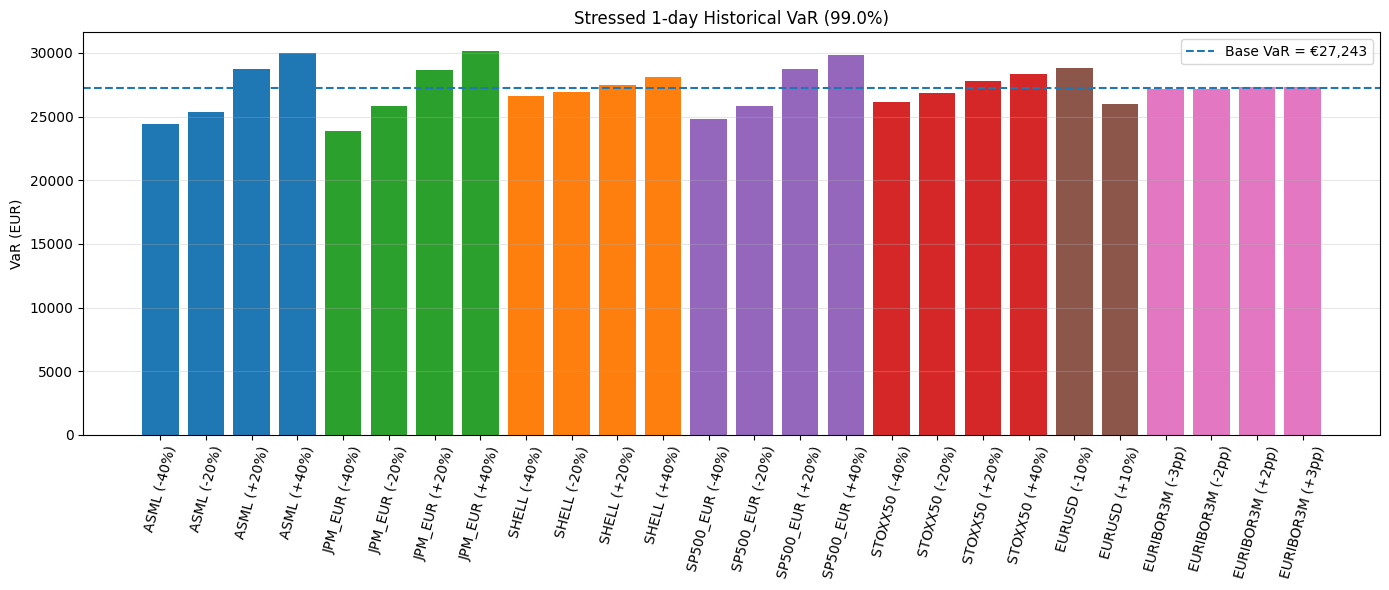

In [175]:
# Plot stressed VaR vs base VaR
plot_df = stress_results.copy()
plot_df["scenario"] = plot_df.apply(
    lambda x: f"{x['factor']} ({x['shock']*100:+.0f}%)" if x["factor"] != "EURIBOR3M"
    else f"{x['factor']} ({x['shock']*100:+.0f}pp)",
    axis=1
)

# Assign distinct colors per stressed factor
factor_colors = {
    "ASML": "#1f77b4",
    "SHELL": "#ff7f0e",
    "JPM_EUR": "#2ca02c",
    "STOXX50": "#d62728",
    "SP500_EUR": "#9467bd",
    "EURUSD": "#8c564b",
    "EURIBOR3M": "#e377c2",
}
bar_colors = plot_df["factor"].map(factor_colors).fillna("#7f7f7f")

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(plot_df["scenario"], plot_df["stressed_VaR_eur"], color=bar_colors)
ax.axhline(base_var, linestyle="--", linewidth=1.5, label=f"Base VaR = €{base_var:,.0f}")
ax.set_title(f"Stressed 1-day Historical VaR ({ALPHA_STRESS*100:.1f}%)")
ax.set_ylabel("VaR (EUR)")
ax.tick_params(axis="x", rotation=75)
ax.grid(True, axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / "06_stressed_var_barplot.png", dpi=150, bbox_inches="tight")
plt.show()

In [176]:
# Sort by most severe impact

worst_pnl = stress_results.sort_values("instant_PnL_eur").head(10)
worst_var = stress_results.sort_values("stressed_VaR_eur", ascending=False).head(10)

print("Worst immediate mark-to-market scenarios")
print(worst_pnl[["factor_type", "factor", "shock", "instant_PnL_eur"]].round(0))

print("Highest stressed VaR scenarios")
print(worst_var[["factor_type", "factor", "shock", "stressed_VaR_eur", "delta_VaR_eur"]].round(0))


Worst immediate mark-to-market scenarios
     factor_type     factor  shock  instant_PnL_eur
16  Equity/Index  SP500_EUR   -0.0         -96000.0
8   Equity/Index    JPM_EUR   -0.0         -96000.0
0   Equity/Index       ASML   -0.0         -64000.0
25          Rate  EURIBOR3M    0.0         -54811.0
9   Equity/Index    JPM_EUR   -0.0         -48000.0
17  Equity/Index  SP500_EUR   -0.0         -48000.0
21            FX     EURUSD    0.0         -43636.0
24          Rate  EURIBOR3M    0.0         -36540.0
1   Equity/Index       ASML   -0.0         -32000.0
4   Equity/Index      SHELL   -0.0         -32000.0
Highest stressed VaR scenarios
     factor_type     factor  shock  stressed_VaR_eur  delta_VaR_eur
11  Equity/Index    JPM_EUR    0.0           30117.0         2874.0
3   Equity/Index       ASML    0.0           30020.0         2777.0
19  Equity/Index  SP500_EUR    0.0           29832.0         2589.0
20            FX     EURUSD   -0.0           28837.0         1595.0
2   Equity/Index